In [54]:
import pandas as pd
import numpy as np

#### Limpieza inicial

In [55]:
salud19 = pd.read_csv('..\ENDES_2019-2023\CSALUD_2019.csv')
salud20 = pd.read_csv('..\ENDES_2019-2023\CSALUD_2020.csv')
salud21 = pd.read_csv('..\ENDES_2019-2023\CSALUD_2021.csv')
salud22 = pd.read_csv('..\ENDES_2019-2023\CSALUD_2022.csv')
salud23 = pd.read_csv('..\ENDES_2019-2023\CSALUD_2023.csv')

aux_map = {"LONGITUDX": "longitudx",
           "LATITUDY": "latitudy"}
salud22 = salud22.rename(columns=aux_map)
salud23 = salud23.rename(columns=aux_map)

salud = pd.concat([salud19, salud20, salud21, salud22, salud23])

salud.columns = salud.columns.str.lower()
salud

,id1,hhid,qhcluster,qhnumber,qhhome,qsnumero,qsresult,qs20c,qssexo,qs23,...,hv023,hv024,hv025,hv026,ubigeo,nconglome,codccpp,nomccpp,longitudx,latitudy
0,2019,100201,1,2,1,2,1,2,2,33,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
1,2019,102801,1,28,1,2,1,2,2,36,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
2,2019,104801,1,48,1,2,1,2,2,28,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
3,2019,113601,1,136,1,2,1,2,2,30,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
4,2019,113701,1,137,1,2,2,,,,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,5429,34,1,2,2,,,,...,18,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37482,2023,542904501,5429,45,1,2,1,2,2,56,...,18,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37483,2023,542904701,5429,47,1,1,1,1,1,67,...,18,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37484,2023,542904901,5429,49,1,4,5,4,2,55,...,18,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538


In [56]:
columnas_dict = {
    "id1": "anio",
    "hhid": "id_hogar",
    "qhcluster": "conglomerado",
    "qhnumber": "vivienda",
    "qhhome": "hogar",
    "qsnumero": "num_persona",
    "qsresult": "cod_resultado",
    "qs20c": "cod_persona",
    "qssexo": "sexo",
    "qs23": "edad",
    "qs24": "asistio_escuela",
    "qs25n": "nivel_aprobado",
    "qs26": "seguro_salud",
    "qs27": "institucion_seguro",
    "qs102": "diagnostico_hipertension",
    "qs903s": "presion_sis_1",
    "qs903d": "presion_dia_1",
    "qs905s": "presion_sis_2",
    "qs905d": "presion_dia_2",
    "qs906": "resultado_presion",
    "qs201": "fumo_30d",
    "qs202": "fuma_diario",
    "qs210": "alcohol_30d",
    "qs215u": "dias_jugo_unidad",
    "qs215c": "dias_jugo",
    "qs900": "peso_kg",
    "qs901": "talla_cm",
    "qs902": "resultado_antropometria",
    "qs907": "perimetro_abdominal_cm",
    "qs908": "resultado_perimetro_abd",
    "hv023": "dominio",
    "hv024": "region",
    "hv025": "area_residencia",
    "hv026": "lugar_residencia",
    "ubigeo": "codigo_ubicacion_geo",
    "nconglome": "num_conglomerado",
    "codccpp": "codigo_centro_poblado",
    "nomccpp": "nombre_centro_poblado",
    "latitudy": "latitud",
    "longitudx": "longitud",

    # "qs700a" : "poco_interes_14d",
    # "qs700b" : "deprimido_14d"
}

In [57]:
salud_mental = [
    "qs700a", "qs700b", "qs700c", "qs700d", "qs700e", "qs700f", "qs700g", "qs700h", "qs700i",
    "qs702", "qs703", "qs704a", "qs704b", "qs704c", "qs704d", "qs704e", "qs704f", "qs704g",
    "qs704h", "qs704i", "qs706", "qs709"
]

salud.drop(columns=salud_mental, inplace=True)

# Renombramos las columnas según el mapeo
for col in salud.columns:
    salud.rename(columns={col: columnas_dict[col]}, inplace=True)

salud

,anio,id_hogar,conglomerado,vivienda,hogar,num_persona,cod_resultado,cod_persona,sexo,edad,...,dominio,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud
0,2019,100201,1,2,1,2,1,2,2,33,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
1,2019,102801,1,28,1,2,1,2,2,36,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
2,2019,104801,1,48,1,2,1,2,2,28,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
3,2019,113601,1,136,1,2,1,2,2,30,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
4,2019,113701,1,137,1,2,2,,,,...,1,1,1,1,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,5429,34,1,2,2,,,,...,18,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37482,2023,542904501,5429,45,1,2,1,2,2,56,...,18,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37483,2023,542904701,5429,47,1,1,1,1,1,67,...,18,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37484,2023,542904901,5429,49,1,4,5,4,2,55,...,18,18,2,3,180202,4381201,1,CHOJATA,-70.73015,-16.388538


In [58]:
estado_encuesta = {
    "1": "completa",
    "2": "ausente",
    "3": "aplazada",
    "4": "rechazada",
    "5": "incompleta",
    "6": "discapacitado",
    "9": "otra"
}
salud["cod_resultado"] = salud["cod_resultado"].map(estado_encuesta)

sexo_dict = {
    "1": "hombre",
    "2": "mujer"
}
salud["sexo"] = salud["sexo"].map(sexo_dict)

boolean_dict = {
    "1": "si",
    "2": "no"
}
salud["asistio_escuela"] = salud["asistio_escuela"].map(boolean_dict)

nivel_educativo_dict = {
    "0": "inicial_preescolar",
    "1": "primaria",
    "2": "secundaria",
    "3": "superior_no_universitaria",
    "4": "superior_universitaria",
    "5": "postgrado"
}
salud["nivel_aprobado"] = salud["nivel_aprobado"].map(nivel_educativo_dict)

salud["seguro_salud"] = salud["seguro_salud"].map(boolean_dict)

respuesta_dict = {
    "1": "si",
    "2": "no",
    "8": "no_sabe_no_recuerda"
}
salud["diagnostico_hipertension"] = salud["diagnostico_hipertension"].map(respuesta_dict)

medicion_dict = {
    "1": "medido",
    "2": "no_presente",
    "3": "rechazo",
    "6": "otro"
}
salud["resultado_presion"] = salud["resultado_presion"].map(medicion_dict)

salud["fumo_30d"] = salud["fumo_30d"].map(respuesta_dict)

salud["fuma_diario"] = salud["fuma_diario"].map(boolean_dict)

salud["alcohol_30d"] = salud["alcohol_30d"].map(respuesta_dict)

dias_consumo_dict = {
    "1": "numero_dias",
    "3": "no_tomo",
    "8": "no_sabe_no_recuerda"
}
salud["dias_jugo_unidad"] = salud["dias_jugo_unidad"].map(dias_consumo_dict)

medicion_dict = {
    "1": "medido",
    "2": "no_presente",
    "3": "rechazo",
    "4": "evaluado_c_hogar",
    "5": "medido_parcialmente",
    "6": "otro"
}
salud["resultado_antropometria"] = salud["resultado_antropometria"].map(medicion_dict)

salud["resultado_perimetro_abd"] = salud["resultado_perimetro_abd"].map(medicion_dict)

regiones_dict = {
    1: "amazonas",
    2: "ancash",
    3: "apurimac",
    4: "arequipa",
    5: "ayacucho",
    6: "cajamarca",
    7: "callao",
    8: "cusco",
    9: "huancavelica",
    10: "huanuco",
    11: "ica",
    12: "junin",
    13: "la_libertad",
    14: "lambayeque",
    15: "lima",
    16: "loreto",
    17: "madre_de_dios",
    18: "moquegua",
    19: "pasco",
    20: "piura",
    21: "puno",
    22: "san_martin",
    23: "tacna",
    24: "tumbes",
    25: "ucayali"
}
salud["dominio"] = salud["dominio"].map(regiones_dict)

salud["region"] = salud["region"].map(regiones_dict)

area_residencia_dict = {
    1: "urbano",
    2: "rural"
}
salud["area_residencia"] = salud["area_residencia"].map(area_residencia_dict)

lugar_residencia_dict = {
    0: "capital_gran_ciudad",
    1: "pequena_ciudad",
    2: "pueblo",
    3: "campo"
}
salud["lugar_residencia"] = salud["lugar_residencia"].map(lugar_residencia_dict)

In [59]:
salud["presion_sis_1"] = pd.to_numeric(salud["presion_sis_1"], errors="coerce")

salud["peso_kg"] = pd.to_numeric(salud["peso_kg"], errors="coerce")
salud["talla_cm"] = pd.to_numeric(salud["talla_cm"], errors="coerce")

salud["perimetro_abdominal_cm"] = pd.to_numeric(salud["perimetro_abdominal_cm"], errors="coerce")

In [60]:
# salud.to_excel("salud.xlsx", index=False)

#### Plots antiguos

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# print(salud.institucion_seguro.value_counts())

In [10]:
# plt.figure(figsize=(12, 8))
# sns.scatterplot(data=salud[(salud.longitud < -60) & (salud.latitud > -30)],
#                 x='longitud',
#                 y='latitud',
#                 hue='diagnostico_hipertension',
#                 palette="coolwarm", alpha=0.6)

# plt.title("Distribución de la Hipertensión por Ubicación")
# plt.xlabel("Longitud")
# plt.ylabel("Latitud")
# plt.legend(title="Hipertensión")
# plt.show()


In [11]:
# sns.boxplot(data=presion_agrupada, y='region', x='presion_sis_1', orient="h")
# plt.title("Presión Sistólica por Región")
# plt.xlabel("Región")
# plt.ylabel("Presión Sistólica")
# plt.show()

In [12]:
# presion_agrupada = salud.groupby(["region", "anio"]).agg({"presion_sis_1": "mean", "id_hogar": "count"}).reset_index()
# display(presion_agrupada)
# presion_agrupada.columns = ["region", "anio", "presion_sis_1", "conteo"]
# # PROMEDIAR AMBAS MEDICIONES DE SISTOLE

# plt.figure(figsize=(12, 6))
# sns.lineplot(data=presion_agrupada, x='anio', y='presion_sis_1', hue='region')
# plt.title("Presión Sistólica Promedio por Año y Región")
# plt.xticks(presion_agrupada.anio.unique())
# plt.xlabel("Año")
# plt.ylabel("Presión Sistólica Promedio")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.show()

In [13]:
# porc_seguro_por_region = salud.groupby(["region", "anio", "seguro_salud"]).agg({"id_hogar": "count"}).reset_index()
# display(porc_seguro_por_region)
# porc_seguro_por_region.columns = ["region", "anio", "seguro_salud", "conteo"]
# porc_seguro_por_region = porc_seguro_por_region.pivot_table(index=["region", "anio"], columns="seguro_salud", values="conteo").reset_index()
# display(porc_seguro_por_region)
# porc_seguro_por_region["total"] = porc_seguro_por_region["si"] + porc_seguro_por_region["no"]
# porc_seguro_por_region["porcentaje_seguro"] = porc_seguro_por_region["si"] / porc_seguro_por_region["total"] * 100
# display(porc_seguro_por_region)

In [14]:
# plt.figure(figsize=(12, 6))
# sns.lineplot(data=porc_seguro_por_region, x='anio', y='porcentaje_seguro', hue='region')
# plt.title("Porcentaje de Personas con Seguro de Salud por Año y Región")
# plt.xticks(porc_seguro_por_region.anio.unique())
# plt.xlabel("Año")
# plt.ylabel("Porcentaje de Personas con Seguro de Salud")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.show()

In [15]:
# porc_hipertension_por_region = salud.groupby(["region", "anio", "diagnostico_hipertension"]).agg({"id_hogar": "count"}).reset_index()
# porc_hipertension_por_region.columns = ["region", "anio", "diagnostico_hipertension", "conteo"]
# porc_hipertension_por_region = porc_hipertension_por_region.pivot_table(index=["region", "anio"], columns="diagnostico_hipertension", values="conteo").reset_index()
# porc_hipertension_por_region["total"] = porc_hipertension_por_region["si"] + porc_hipertension_por_region["no"]
# porc_hipertension_por_region["porcentaje_hipertension"] = porc_hipertension_por_region["si"] / porc_hipertension_por_region["total"] * 100

In [16]:
# plt.figure(figsize=(12, 6))
# sns.lineplot(data=porc_hipertension_por_region, x='anio', y='porcentaje_hipertension', hue='region')
# plt.title("Porcentaje de Personas con Hipertensión por Año y Región")
# plt.xticks(porc_hipertension_por_region.anio.unique())
# plt.xlabel("Año")
# plt.ylabel("Porcentaje de Personas con Hipertensión")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.show()

In [17]:
display(salud)

,anio,id_hogar,conglomerado,vivienda,hogar,num_persona,cod_resultado,cod_persona,sexo,edad,...,dominio,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud
0,2019,100201,1,2,1,2,completa,2,mujer,33,...,amazonas,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
1,2019,102801,1,28,1,2,completa,2,mujer,36,...,amazonas,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
2,2019,104801,1,48,1,2,completa,2,mujer,28,...,amazonas,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
3,2019,113601,1,136,1,2,completa,2,mujer,30,...,amazonas,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
4,2019,113701,1,137,1,2,ausente,,NaN,,...,amazonas,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,5429,34,1,2,ausente,,NaN,,...,moquegua,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37482,2023,542904501,5429,45,1,2,completa,2,mujer,56,...,moquegua,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37483,2023,542904701,5429,47,1,1,completa,1,hombre,67,...,moquegua,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538
37484,2023,542904901,5429,49,1,4,incompleta,4,mujer,55,...,moquegua,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538


#### LIMPIEZA E IMPUTACIÓN DE ROWS

In [ ]:
display(salud)

* num_persona

In [13]:
#convierte los valores de la columna num_persona " " a nan
salud["num_persona"] = pd.to_numeric(salud["num_persona"], errors="coerce")

print(salud["num_persona"].isna().sum())

15546


In [14]:
#imputa los valores nan de la columna num_persona de salud con el valor 0
salud["num_persona"].fillna(0, inplace=True)

#convierte la columna num_persona a objeto
salud["num_persona"] = salud["num_persona"].astype(str)

C:\Users\dial_\AppData\Local\Temp\ipykernel_16152\118645622.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  salud["num_persona"].fillna(0, inplace=True)


Estoy creando un id_encuesta porque hay 35 645 row con el mismo id_hogar, pero son diferentes encuestas, en diferentes años y posiblemente diferentes personas. 

In [15]:
#muestrame los row de salud donde la columna id_hogar se repite
(salud[salud.duplicated(subset=["id_hogar"], keep=False)])

,anio,id_hogar,conglomerado,vivienda,hogar,num_persona,cod_resultado,cod_persona,sexo,edad,...,dominio,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud
1,2019,102801,1,28,1,2.0,completa,2,mujer,36,...,amazonas,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.873830,-6.223320
42,2019,501101,5,11,1,5.0,completa,5,mujer,20,...,amazonas,amazonas,urbano,pequena_ciudad,10101,7088,1,CHACHAPOYAS,-77.857490,-6.234700
46,2019,508001,5,80,1,1.0,completa,1,hombre,32,...,amazonas,amazonas,urbano,pequena_ciudad,10101,7088,1,CHACHAPOYAS,-77.857490,-6.234700
47,2019,509801,5,98,1,2.0,completa,2,mujer,50,...,amazonas,amazonas,urbano,pequena_ciudad,10101,7088,1,CHACHAPOYAS,-77.857490,-6.234700
52,2019,602501,6,25,1,3.0,completa,3,mujer,79,...,amazonas,amazonas,urbano,pequena_ciudad,10101,7097,1,CHACHAPOYAS,-77.872510,-6.234240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24925,2023,433902201,4339,22,1,2.0,completa,2,hombre,26,...,ucayali,ucayali,rural,campo,250106,15618,23,LOS ANGELES,-74.976777,-8.345460
24926,2023,433902401,,,,0.0,NaN,,NaN,,...,ucayali,ucayali,rural,campo,250106,15618,23,LOS ANGELES,-74.976777,-8.345460
24927,2023,433902501,4339,25,1,1.0,completa,1,hombre,27,...,ucayali,ucayali,rural,campo,250106,15618,23,LOS ANGELES,-74.976777,-8.345460
24968,2023,434200801,4342,8,1,2.0,completa,2,mujer,43,...,junin,junin,rural,campo,120302,31199,37,LOS ZORZALES,-75.143710,-10.834600


In [16]:
#crea una columna id_encuesta en salud por cada row y llena de 1 a n
salud["id_encuesta"] = range(1, len(salud) + 1)

* edad

In [17]:
salud["edad"] = pd.to_numeric(salud["edad"], errors="coerce")
print(salud["edad"].isna().sum())

25204


In [18]:
#MEDIANA POR DOMINIO
mediana_edad = salud.groupby("dominio")["edad"].median()

#IMPUTACIÓN
salud.loc[salud["edad"].isna(), "edad"] = (
    salud.loc[salud["edad"].isna(), "dominio"].map(mediana_edad)
    + np.random.randint(-3, 4, size=salud["edad"].isna().sum()) # del 2019 al 2023
).round(0)

Las variables sexo y diagnóstico_hipertension se imputa utilizando choice(["a", "b"]) porque son categóricas binaria, donde solo existen dos posibles respuestas. 

* sexo

In [19]:
print(salud["sexo"].isna().sum())

# #convierte los nan en "Desconocido"
# salud["sexo"].fillna("Desconocido", inplace=True)

print(salud["sexo"].value_counts())

25203
sexo
mujer     92087
hombre    70582
Name: count, dtype: int64


In [20]:
from scipy.stats import chi2_contingency

for col in ["dominio", "area_residencia", "lugar_residencia"]:
    tabla = pd.crosstab(salud[col], salud["sexo"])
    chi2, p, dof, ex = chi2_contingency(tabla)
    print(f"{col} - p-valor: {p:.4f}")

dominio - p-valor: 0.0000
area_residencia - p-valor: 0.0000
lugar_residencia - p-valor: 0.0000


In [21]:
#IMPUTACIÓN DE SEXO
probs_sexo = salud.groupby("dominio")["sexo"].value_counts(normalize=True).unstack()

def imputar_sexo(row):
    if pd.isna(row["sexo"]):
        return np.random.choice(["hombre", "mujer"], p=[probs_sexo.loc[row["dominio"], "hombre"], probs_sexo.loc[row["dominio"], "mujer"]])
    return row["sexo"]

salud["sexo"] = salud.apply(imputar_sexo, axis=1)

print(salud["sexo"].value_counts())
len(salud["sexo"])

sexo
mujer     106373
hombre     81499
Name: count, dtype: int64


187872

* diagnostico_hipertension

In [22]:
print(salud["diagnostico_hipertension"].value_counts())
print(salud["diagnostico_hipertension"].isna().sum())

diagnostico_hipertension
no                     148778
si                      13716
no_sabe_no_recuerda       173
Name: count, dtype: int64
25205


In [23]:
#convertir los valores no_sabe_no_recuerda a nan
salud["diagnostico_hipertension"] = salud["diagnostico_hipertension"].replace("no_sabe_no_recuerda", np.nan)
print(salud["diagnostico_hipertension"].isna().sum())

25378


In [24]:
#IMPUTACIÓN DE HIPERTENSIÓN
probs_hipertension = salud.groupby("dominio")["diagnostico_hipertension"].value_counts(normalize=True).unstack()

def imputar_hipertension(row):
    if pd.isna(row["diagnostico_hipertension"]):
        return np.random.choice(["si", "no"], p=[probs_hipertension.loc[row["dominio"], "si"], probs_hipertension.loc[row["dominio"], "no"]])
    return row["diagnostico_hipertension"]

salud["diagnostico_hipertension"] = salud.apply(imputar_hipertension, axis=1)

print(salud["diagnostico_hipertension"].value_counts())

diagnostico_hipertension
no    171992
si     15880
Name: count, dtype: int64


* peso_kg, talla_cm, perimetro_abdominal_cm

In [25]:
print(salud["peso_kg"].isna().sum())
print(salud["talla_cm"].isna().sum())
print(salud["perimetro_abdominal_cm"].isna().sum())

33703
33703
33697


In [26]:
# limpieza de los que tienen 999.9
salud["peso_kg"] = salud["peso_kg"].replace(999.9, np.nan)
salud["talla_cm"] = salud["talla_cm"].replace(999.9, np.nan)
salud["perimetro_abdominal_cm"] = salud["perimetro_abdominal_cm"].replace(999.9, np.nan)

In [27]:
#MEDIANA POR DOMINIO
peso_media = salud.groupby("dominio").peso_kg.mean()
talla_media = salud.groupby("dominio").talla_cm.mean()
perimetro_media = salud.groupby("dominio").perimetro_abdominal_cm.mean()

# IMPUTACIÓN
salud.loc[salud["peso_kg"].isna(), "peso_kg"] = (
    salud.loc[salud["peso_kg"].isna(), "dominio"].map(peso_media)  
    + np.random.normal(0, 2, size=salud["peso_kg"].isna().sum())  
).round(1)

salud.loc[salud["talla_cm"].isna(), "talla_cm"] = (
    salud.loc[salud["talla_cm"].isna(), "dominio"].map(talla_media) 
    + np.random.normal(0, 1, size=salud["talla_cm"].isna().sum())
).round(1)

salud.loc[salud["perimetro_abdominal_cm"].isna(), "perimetro_abdominal_cm"] = (
    salud.loc[salud["perimetro_abdominal_cm"].isna(), "dominio"].map(perimetro_media)  
    + np.random.normal(0, 3, size=salud["perimetro_abdominal_cm"].isna().sum()) 
).round(1)


In [28]:
print(salud["peso_kg"].isna().sum())
print(salud["talla_cm"].isna().sum())
print(salud["perimetro_abdominal_cm"].isna().sum())

0
0
0


* presion_sis_1, presion_sis_2, presion_dia_1, presion_dia_2

In [29]:
salud["presion_sis_1"] = pd.to_numeric(salud["presion_sis_1"], errors="coerce")
salud["presion_sis_2"] = pd.to_numeric(salud["presion_sis_2"], errors="coerce")
salud["presion_dia_1"] = pd.to_numeric(salud["presion_dia_1"], errors="coerce")
salud["presion_dia_2"] = pd.to_numeric(salud["presion_dia_2"], errors="coerce")

In [30]:
#limpieza de los que tienen 999.0 a nan
salud["presion_sis_1"] = salud["presion_sis_1"].replace(999.0, np.nan)
salud["presion_sis_2"] = salud["presion_sis_2"].replace(999.0, np.nan)
salud["presion_dia_1"] = salud["presion_dia_1"].replace(999.0, np.nan)
salud["presion_dia_2"] = salud["presion_dia_2"].replace(999.0, np.nan)

print(salud["presion_sis_1"].isna().sum())
print(salud["presion_sis_2"].isna().sum())
print(salud["presion_dia_1"].isna().sum())
print(salud["presion_dia_2"].isna().sum())

36185
36185
36185
36185


In [31]:
#MEDIANA POR DOMINIO
presion_sis_1_media = salud.groupby("dominio").presion_sis_1.mean()
presion_sis_2_media = salud.groupby("dominio").presion_sis_2.mean()
presion_dia_1_media = salud.groupby("dominio").presion_dia_1.mean()
presion_dia_2_media = salud.groupby("dominio").presion_dia_2.mean()

# IMPUTACIÓN
salud.loc[salud["presion_sis_1"].isna(), "presion_sis_1"] = (
    salud.loc[salud["presion_sis_1"].isna(), "dominio"].map(presion_sis_1_media)  
    + np.random.normal(0, 5, size=salud["presion_sis_1"].isna().sum())  
).round(0)

salud.loc[salud["presion_sis_2"].isna(), "presion_sis_2"] = (
    salud.loc[salud["presion_sis_2"].isna(), "dominio"].map(presion_sis_2_media)  
    + np.random.normal(0, 4, size=salud["presion_sis_2"].isna().sum())  
).round(0)

salud.loc[salud["presion_dia_1"].isna(), "presion_dia_1"] = (
    salud.loc[salud["presion_dia_1"].isna(), "dominio"].map(presion_dia_1_media)  
    + np.random.normal(0, 3, size=salud["presion_dia_1"].isna().sum())  
).round(0)

salud.loc[salud["presion_dia_2"].isna(), "presion_dia_2"] = (
    salud.loc[salud["presion_dia_2"].isna(), "dominio"].map(presion_dia_2_media)  
    + np.random.normal(0, 2, size=salud["presion_dia_2"].isna().sum())  
).round(0)

print(salud["presion_sis_1"].isna().sum())
print(salud["presion_sis_2"].isna().sum())
print(salud["presion_dia_1"].isna().sum())
print(salud["presion_dia_2"].isna().sum())

0
0
0
0


#### MODELO RANDOM FOREST PARA IMPUTACIÓN DE EDAD Y SEXO

In [471]:
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [472]:
# # SET DE ENTRENAMIENTO
# XY = salud[["sexo", "dominio", "area_residencia", "lugar_residencia", "anio"]].dropna().to_numpy()
# print(XY)

In [473]:
# # x train y train
# x_train = XY[:,1:5]
# y_train = XY[:,0]
# print(x_train)

In [474]:
# print(y_train)

In [475]:
# # SET DE PRUEBA
# filas = salud[~salud['sexo'].notna()].index

# x_test = salud[["dominio", "area_residencia", "lugar_residencia", "anio"]].iloc[filas].to_numpy()
# print(x_test)

In [476]:
# print(x_train)

In [477]:
# he = OneHotEncoder()
# le = LabelEncoder()

# he.fit(x_train[:,0:3])
# x_train_encoded = he.transform(x_train[:,0:3]).toarray()
# x_train = np.hstack([x_train_encoded, x_train[:,3].reshape(-1,1)])

# le.fit(y_train)
# y_train = le.transform(y_train)

# he.fit(x_test[:,0:3])
# x_test_encoded = he.transform(x_test[:,0:3]).toarray()
# x_test = np.hstack([x_test_encoded, x_test[:,3].reshape(-1,1)])

In [478]:
# from imblearn.over_sampling import SMOTE
# from collections import Counter

# # Aplicar SMOTE al conjunto de entrenamiento
# smote = SMOTE(sampling_strategy='auto', random_state=42)
# x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)

# print("Distribución después de SMOTE:", Counter(y_train_bal))

In [479]:
# # Entrenar el modelo con los datos balanceados
# rf = RandomForestClassifier(n_estimators=300, random_state=42)
# rf.fit(x_train_bal, y_train_bal)
# preds = rf.predict(x_test)
# print(preds)


In [480]:
# acc=accuracy_score(y_train, rf.predict(x_train))
# print(acc)

In [481]:
# feature_importance = rf.feature_importances_

# # Crear DataFrame con índices numéricos
# features = pd.DataFrame({'Feature': np.arange(len(feature_importance)), 'Importance': feature_importance})

# # Ordenar y mostrar
# features = features.sort_values(by='Importance', ascending=False)
# print(features.head(10))

In [482]:
# # from scipy.stats import ks_2samp

# # for col in features:
# #     stat, p_value = ks_2samp(salud[col].dropna(), salud_imputed[col])
# #     print(f"{col}: p-value = {p_value:.4f}")


#### MODELO RANOOM FOREST REGRESSOR PARA IMPUTACIÓN DE PESO, TALLA, PERÍMETRO ABDOMINAL Y PRESIONES

In [483]:
from sklearn.ensemble import RandomForestRegressor

In [491]:
features = ["edad", "peso_kg", "talla_cm", "perimetro_abdominal_cm", 
            "presion_sis_1", "presion_sis_2", "presion_dia_1", "presion_dia_2"]

In [ ]:
#ONE HOT ENCODING
he = OneHotEncoder()

categorical_cols = ["area_residencia", "lugar_residencia", "dominio", "sexo"]

categoricals_col_encoded = he.fit[:,0,4].toarray()



salud_encoded = pd.get_dummies(salud, columns=categorical_cols, drop_first=True)

In [493]:
selected_columns = features + ["anio"] + list(salud_encoded.columns.difference(salud.columns))

X = salud_encoded[selected_columns]

In [ ]:
#ESTANDARIZACIÓN DE DATOS
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[features] = scaler.fit_transform(X[features])

In [ ]:
# # GRUPOS CORRELACIONADOS
# grupo_presion = ["presion_sis_1", "presion_sis_2", "presion_dia_1", "presion_dia_2"]
# grupo_antropometrico = ["edad", "peso_kg", "talla_cm", "perimetro_abdominal_cm"]

In [490]:
display(salud)

,anio,id_hogar,conglomerado,vivienda,hogar,num_persona,cod_resultado,cod_persona,sexo,edad,...,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud,id_encuesta
0,2019,100201,1,2,1,2.0,completa,2,mujer,33.0,...,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,1
1,2019,102801,1,28,1,2.0,completa,2,mujer,36.0,...,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,2
2,2019,104801,1,48,1,2.0,completa,2,mujer,28.0,...,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,3
3,2019,113601,1,136,1,2.0,completa,2,mujer,30.0,...,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,4
4,2019,113701,1,137,1,2.0,ausente,,hombre,NaN,...,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,5429,34,1,2.0,ausente,,mujer,NaN,...,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538,187868
37482,2023,542904501,5429,45,1,2.0,completa,2,mujer,56.0,...,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538,187869
37483,2023,542904701,5429,47,1,1.0,completa,1,hombre,67.0,...,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538,187870
37484,2023,542904901,5429,49,1,4.0,incompleta,4,mujer,55.0,...,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538,187871


In [ ]:
# Aplicar KNN Imputation with k=5 (can be adjusted based on validation)
from sklearn.impute import KNNImputer


imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_scaled)

# Convert back to DataFrame
salud_imputed = pd.DataFrame(X_imputed, columns=X.columns)

# Undo the standardization
salud_imputed[features] = scaler.inverse_transform(salud_imputed[features])

# Replace imputed values in the original dataset
salud[features] = salud_imputed[features]

C:\Users\dial_\AppData\Local\Temp\ipykernel_14280\3177160847.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[grupo_presion] = rf_imputer_presion.fit_transform(X[grupo_presion])
c:\Users\dial_\anaconda3\envs\salud_minds\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\dial_\AppData\Local\Temp\ipykernel_14280\3177160847.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[grupo_antropometrico] = 

In [ ]:
# salud.loc[:, grupo_presion] = X[grupo_presion]
# salud.loc[:, grupo_antropometrico] = X[grupo_antropometrico]

In [ ]:
# #exporta el archivo salud
# salud.to_excel("salud.xlsx", index=False)

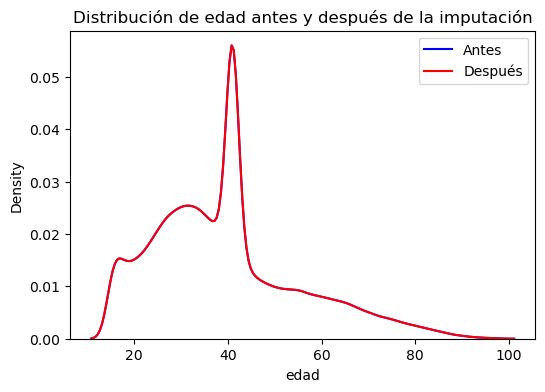

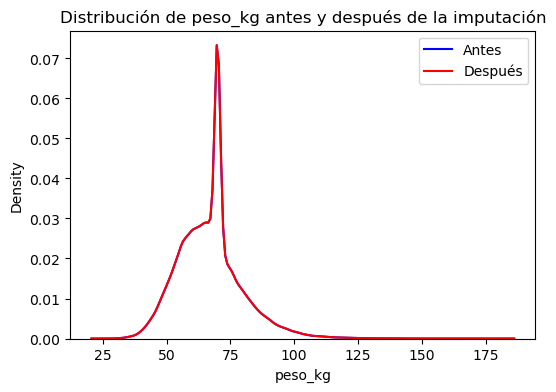

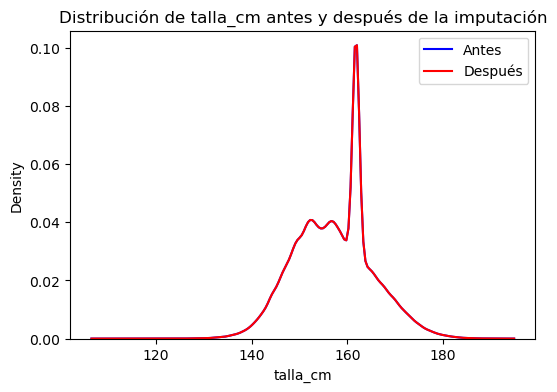

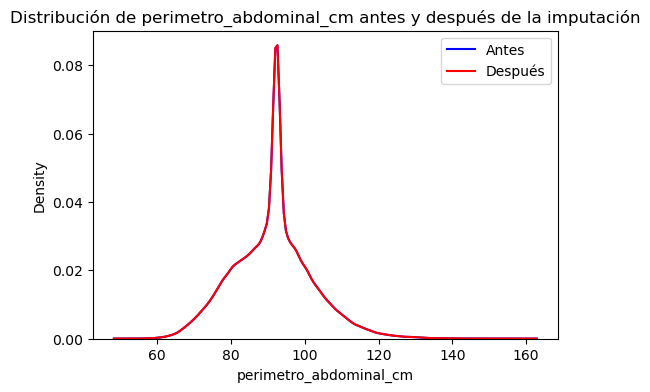

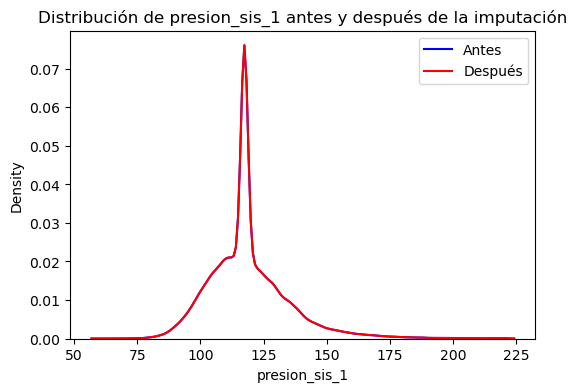

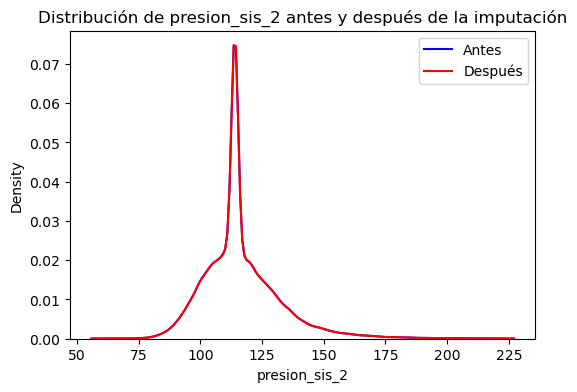

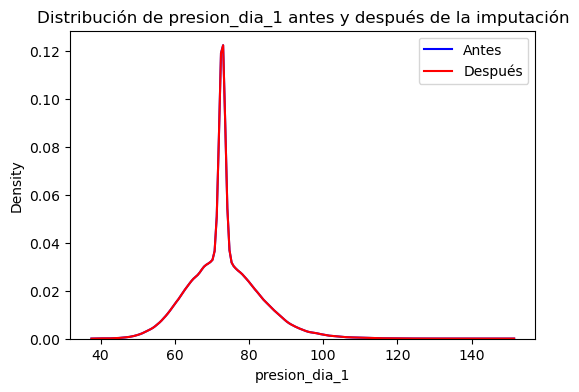

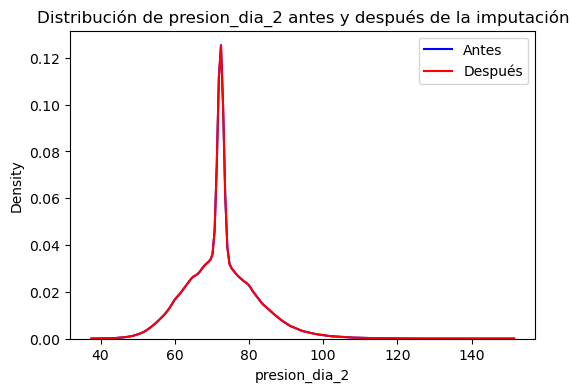

In [498]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in features:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(salud[col].dropna(), label="Antes", color="blue")
    sns.kdeplot(X[col], label="Después", color="red")
    plt.title(f"Distribución de {col} antes y después de la imputación")
    plt.legend()
    plt.show()


In [44]:
print(salud["edad"].isna().sum())
print(salud["peso_kg"].isna().sum())
print(salud["talla_cm"].isna().sum())
print(salud["perimetro_abdominal_cm"].isna().sum())
print(salud["presion_sis_1"].isna().sum())
print(salud["presion_sis_2"].isna().sum())
print(salud["presion_dia_1"].isna().sum())
print(salud["presion_dia_2"].isna().sum())

0
0
0
0
0
0
0
0


#### EXCLUSIÓN DE MENORES DE 18 AÑOS

In [32]:
#eliminar de salud los rows con edad menor a 18
salud = salud[salud["edad"] >= 18]
display(salud)

,anio,id_hogar,conglomerado,vivienda,hogar,num_persona,cod_resultado,cod_persona,sexo,edad,...,region,area_residencia,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud,id_encuesta
0,2019,100201,1,2,1,2.0,completa,2,mujer,33.0,...,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,1
1,2019,102801,1,28,1,2.0,completa,2,mujer,36.0,...,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,2
2,2019,104801,1,48,1,2.0,completa,2,mujer,28.0,...,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,3
3,2019,113601,1,136,1,2.0,completa,2,mujer,30.0,...,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,4
4,2019,113701,1,137,1,2.0,ausente,,hombre,35.0,...,amazonas,urbano,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,5429,34,1,2.0,ausente,,mujer,35.0,...,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538,187868
37482,2023,542904501,5429,45,1,2.0,completa,2,mujer,56.0,...,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538,187869
37483,2023,542904701,5429,47,1,1.0,completa,1,hombre,67.0,...,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538,187870
37484,2023,542904901,5429,49,1,4.0,incompleta,4,mujer,55.0,...,moquegua,rural,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538,187871


#### IMC: NCBI

In [33]:
salud["imc"] = salud["peso_kg"] / (salud["talla_cm"] / 100) ** 2

C:\Users\dial_\AppData\Local\Temp\ipykernel_16152\68706645.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  salud["imc"] = salud["peso_kg"] / (salud["talla_cm"] / 100) ** 2


In [38]:
#ESTÁNDARES SEGÚN NCBI
def categorizar_imc(imc):
    if imc < 18.5:
        return "Bajo peso"
    elif imc >= 18.5 and imc <= 24.9:
        return "Peso normal"
    elif imc >= 25.0 and imc <= 29.9:
        return "Sobrepeso"
    elif imc >= 30.0 and imc <= 34.9:
        return "Obesidad Clase I"
    elif imc >= 35.0 and imc <= 39.9:
        return "Obesidad Clase II"
    elif imc >= 40.0:
        return "Obesidad Clase III"
    else:
        return "Valor fuera de rango"  # Para manejar posibles errores


In [39]:
#imprime el número de valores que tiene cada categoría de imc
salud["categoria_imc"] = salud["imc"].apply(categorizar_imc)
salud["categoria_imc"].value_counts()

C:\Users\dial_\AppData\Local\Temp\ipykernel_16152\1065239050.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  salud["categoria_imc"] = salud["imc"].apply(categorizar_imc)


categoria_imc
Sobrepeso               91150
Peso normal             46558
Obesidad Clase I        27532
Obesidad Clase II        6830
Valor fuera de rango     2876
Obesidad Clase III       2027
Bajo peso                1284
Name: count, dtype: int64

In [40]:
#imprime el máximo y mímimo imc por categoría_imc
salud.groupby("categoria_imc")["imc"].agg(["min", "max"])

,min,max
categoria_imc,,
Bajo peso,12.543326,18.499772
Obesidad Clase I,30.000000,34.899958
Obesidad Clase II,35.000000,39.896142
Obesidad Clase III,40.000000,72.886408
Peso normal,18.503240,24.899987
Sobrepeso,25.000416,29.899942
Valor fuera de rango,24.900122,39.997010


In [41]:
print(salud["imc"].describe())
display(salud)

count    178257.000000
mean         27.335725
std           4.283055
min          12.543326
25%          24.671053
50%          27.073020
75%          29.336544
max          72.886408
Name: imc, dtype: float64


,anio,id_hogar,conglomerado,vivienda,hogar,num_persona,cod_resultado,cod_persona,sexo,edad,...,lugar_residencia,codigo_ubicacion_geo,num_conglomerado,codigo_centro_poblado,nombre_centro_poblado,longitud,latitud,id_encuesta,imc,categoria_imc
0,2019,100201,1,2,1,2.0,completa,2,mujer,33.0,...,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,1,26.355556,Sobrepeso
1,2019,102801,1,28,1,2.0,completa,2,mujer,36.0,...,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,2,32.724838,Obesidad Clase I
2,2019,104801,1,48,1,2.0,completa,2,mujer,28.0,...,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,3,34.132280,Obesidad Clase I
3,2019,113601,1,136,1,2.0,completa,2,mujer,30.0,...,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,4,24.638117,Peso normal
4,2019,113701,1,137,1,2.0,ausente,,hombre,35.0,...,pequena_ciudad,10101,7065,1,CHACHAPOYAS,-77.87383,-6.223320,5,25.930253,Sobrepeso
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37481,2023,542903401,5429,34,1,2.0,ausente,,mujer,35.0,...,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538,187868,28.337130,Sobrepeso
37482,2023,542904501,5429,45,1,2.0,completa,2,mujer,56.0,...,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538,187869,25.117073,Sobrepeso
37483,2023,542904701,5429,47,1,1.0,completa,1,hombre,67.0,...,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538,187870,26.770831,Sobrepeso
37484,2023,542904901,5429,49,1,4.0,incompleta,4,mujer,55.0,...,campo,180202,4381201,1,CHOJATA,-70.73015,-16.388538,187871,29.823253,Sobrepeso


#### Limpieza anterior

In [26]:
# #imprime el número de valores únicos en imc con categoria peso muy inferior al normal
# print(salud[salud["categoria_imc"] == "Peso muy inferior al normal"]["imc"].nunique())

In [27]:
# # Calcular la mediana corregida para "Peso muy inferior al normal"
# filtro_valido = (salud["categoria_imc"] == "Peso muy inferior al normal") & (salud["imc"].round(6) > 10.001000)
# if filtro_valido.any():
#     mediana_corregida = salud.loc[filtro_valido, "imc"].median()
#     print(f"Mediana corregida para 'Peso muy inferior al normal': {mediana_corregida}")

# medianas_imc = salud.loc[(salud["imc"] > 10.001) & (salud["imc"] <= 100)].groupby("categoria_imc")["imc"].median()

# if "Peso muy inferior al normal" in medianas_imc.index:
#     print(f"Reemplazando mediana original {medianas_imc['Peso muy inferior al normal']} con {mediana_corregida}")
#     medianas_imc.loc["Peso muy inferior al normal"] = mediana_corregida

# def imputar_imc(row):
#     if row["categoria_imc"] == "Peso muy inferior al normal" and row["imc"] <= 10.05:
#         return mediana_corregida
#     elif row["imc"] > 100 or row["imc"] < 10.001:
#         return medianas_imc.get(row["categoria_imc"], row["imc"])
#     return row["imc"]

In [28]:
# salud["imc"] = salud.apply(imputar_imc, axis=1)
# salud["categoria_imc"] = salud["imc"].apply(categorizar_imc)

In [29]:
# print(medianas_imc)

In [30]:
# # Excluir valores incorrectos antes de calcular la mediana
# medianas_perimetro = salud[salud["perimetro_abdominal_cm"] != 999.9].groupby("categoria_imc")["perimetro_abdominal_cm"].median()
# print(medianas_perimetro)  # Verificar las medianas calculadas


In [31]:
# # Imputar los valores erróneos de 999.9 con la mediana de su categoría de IMC
# def imputar_perimetro(row):
#     if row["perimetro_abdominal_cm"] == 999.9:
#         return medianas_perimetro[row["categoria_imc"]]
#     return row["perimetro_abdominal_cm"]

# salud["perimetro_abdominal_cm"] = salud.apply(imputar_perimetro, axis=1)

In [33]:
# categoria_imc_agrupada = salud.groupby("categoria_imc").size().reset_index(name="count")

In [34]:
# # Imputar los valores NaN con la mediana correspondiente de su categoría
# for categoria, mediana in medianas_perimetro.items():
#     salud.loc[(salud["categoria_imc"] == categoria) & (salud["perimetro_abdominal_cm"].isna()), "perimetro_abdominal_cm"] = mediana

# # Verificar que ya no haya NaN en la columna
# print(salud["perimetro_abdominal_cm"].isna().sum())  # Debería imprimir 0 si todo está bien

In [35]:
# print(salud["imc"].isna().sum())
# print(salud["id_hogar"].isna().sum())

#### Gráfico de dispersión: IMC vs Perímetro abdominal

In [42]:
df_agrupado = salud[["imc", "perimetro_abdominal_cm", "categoria_imc", "id_encuesta"]].copy()

In [43]:
len(df_agrupado)

178257

In [44]:
orden_categorias = {
    "Peso muy inferior al normal": 1,
    "Bajo peso": 2,
    "Peso normal": 3,
    "Sobrepeso": 4,
    "Obesidad Clase I": 5,
    "Obesidad Clase II": 6,
    "Obesidad Clase III": 7
}

In [45]:
df_agrupado["orden"] = df_agrupado["categoria_imc"].map(orden_categorias)
df_agrupado = df_agrupado.sort_values("orden")

In [46]:
salud.groupby("categoria_imc")["perimetro_abdominal_cm"].describe()


,count,mean,std,min,25%,50%,75%,max
categoria_imc,,,,,,,,
Bajo peso,1284.0,69.495561,5.821795,52.3,66.3,69.15,71.9,98.3
Obesidad Clase I,27532.0,101.996604,6.190892,61.6,97.9,102.00,106.1,150.2
Obesidad Clase II,6830.0,110.976823,7.213287,69.5,106.8,111.30,115.6,134.6
Obesidad Clase III,2027.0,121.984361,10.152552,77.2,116.3,121.90,128.0,160.0
Peso normal,46558.0,81.721897,6.351010,51.1,77.4,81.70,86.2,142.1
Sobrepeso,91150.0,92.316427,5.170647,60.5,88.9,92.20,95.6,128.2
Valor fuera de rango,2876.0,93.766898,9.068002,68.8,87.3,92.40,99.0,138.5


In [47]:
plt.figure(figsize=(12, 6))

#scatter plot con categoria imc agrupada
sns.scatterplot(data=df_agrupado, x="imc", y="perimetro_abdominal_cm", hue="categoria_imc", palette="coolwarm", alpha=0.5)

#lineas verticales de referencia para las categorías de IMC
for x in [16.5, 18.5, 25, 30, 35, 40]:
    plt.axvline(x, color='gray', linestyle='--', alpha=0.6)
    
plt.title("IMC vs Perímetro Abdominal")
plt.xlabel("IMC")
plt.ylabel("Perímetro Abdominal")
plt.legend(title="Categoría IMC", bbox_to_anchor=(1, 1))
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# plt.figure(figsize=(12, 6))
# salud_nomissing = salud.dropna(subset=["imc"])
# sns.boxplot(data=salud_nomissing[salud_nomissing["imc"]<300], x="anio", y="imc")
# # sns.violinplot(data=salud_nomissing[salud_nomissing["imc"]<300], x="anio", y="imc", hue="sexo", split=True)

# plt.title("Distribución del IMC por Año")
# plt.xlabel("Año")
# plt.ylabel("IMC")
# plt.show()

In [ ]:
# # perimetro abdominal y sexo
# plt.figure(figsize=(12, 6))
# salud_nomissing = salud.dropna(subset=["perimetro_abdominal_cm"])
# sns.boxplot(data=salud_nomissing[salud_nomissing["perimetro_abdominal_cm"]< 800], x="anio", y="perimetro_abdominal_cm")

# plt.title("Distribución del Perímetro Abdominal por Año")
# plt.xlabel("Año")
# plt.ylabel("Perímetro Abdominal")
# plt.show()

#### HIPERTENSIÓN

In [48]:
# Calcular el promedio de la presión sistólica y diastólica
salud["presion_sis_promedio"] = salud[["presion_sis_1", "presion_sis_2"]].mean(axis=1)
salud["presion_dia_promedio"] = salud[["presion_dia_1", "presion_dia_2"]].mean(axis=1)

C:\Users\dial_\AppData\Local\Temp\ipykernel_16152\2465493461.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  salud["presion_sis_promedio"] = salud[["presion_sis_1", "presion_sis_2"]].mean(axis=1)
C:\Users\dial_\AppData\Local\Temp\ipykernel_16152\2465493461.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  salud["presion_dia_promedio"] = salud[["presion_dia_1", "presion_dia_2"]].mean(axis=1)


In [49]:
len(salud["presion_dia_promedio"])

178257

In [ ]:
# Definir función para categorizar la presión arterial
def categorizar_presion(sistolica, diastolica):
    if sistolica >= 180 or diastolica > 120:
        return "Crisis Hipertensiva (Hipertensión Etapa 3)"
    elif sistolica >= 140 or diastolica >= 90:
        return "Hipertensión Etapa 2"
    elif sistolica >= 130 or diastolica >= 80:
        return "Hipertensión Etapa 1"
    elif sistolica >= 120 and diastolica < 80:
        return "Elevado"
    else:
        return "Normal"

# Aplicar la categorización
salud["categoria_presion"] = salud.apply(
    lambda row: categorizar_presion(row["presion_sis_promedio"], row["presion_dia_promedio"]), axis=1
)


C:\Users\dial_\AppData\Local\Temp\ipykernel_16152\2445744125.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  salud["categoria_presion"] = salud.apply(


In [51]:
print(salud["presion_sis_promedio"].describe())
print(salud["presion_dia_promedio"].describe())
print(salud["categoria_presion"].value_counts())

count    178257.000000
mean        118.707759
std          15.575636
min          62.500000
25%         109.500000
50%         117.500000
75%         125.000000
max         220.000000
Name: presion_sis_promedio, dtype: float64
count    178257.000000
mean         73.351888
std           9.157258
min          40.000000
25%          68.000000
50%          73.000000
75%          77.500000
max         149.000000
Name: presion_dia_promedio, dtype: float64
categoria_presion
Normal                                        98757
Elevado                                       33035
Hipertensión Etapa 1                          29288
Hipertensión Etapa 2                          16097
Crisis Hipertensiva (Hipertensión Etapa 3)     1080
Name: count, dtype: int64


In [52]:
#agrgar diagnostico_hipertension y categoria_presion a df_agrupado
df_agrupado["diagnostico_hipertension"] = salud["diagnostico_hipertension"].values

df_agrupado["categoria_presion"] = salud["categoria_presion"].values
display(df_agrupado)

,imc,perimetro_abdominal_cm,categoria_imc,id_encuesta,orden,diagnostico_hipertension,categoria_presion
8143,18.134830,65.6,Bajo peso,158530,2.0,no,Normal
25717,17.795675,71.4,Bajo peso,176104,2.0,no,Normal
15380,17.713052,72.0,Bajo peso,165767,2.0,no,Hipertensión Etapa 1
17145,18.142938,67.6,Bajo peso,54620,2.0,no,Normal
25863,17.663738,69.4,Bajo peso,25864,2.0,no,Normal
...,...,...,...,...,...,...,...
37358,29.939742,94.9,Valor fuera de rango,187745,NaN,no,Normal
37408,24.955713,93.1,Valor fuera de rango,187795,NaN,no,Normal
37443,34.904261,95.3,Valor fuera de rango,187830,NaN,si,Elevado
37464,24.944231,92.5,Valor fuera de rango,187851,NaN,no,Normal


#### Histograma de promedio de presiones

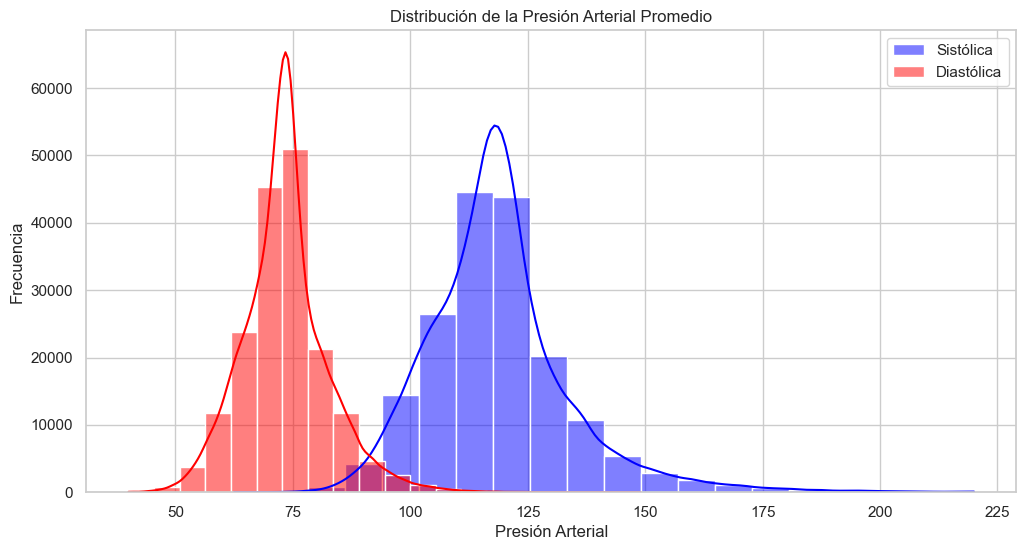

In [544]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(salud["presion_sis_promedio"], bins=20, kde=True, color="blue", label="Sistólica")
sns.histplot(salud["presion_dia_promedio"], bins=20, kde=True, color="red", label="Diastólica")
plt.title("Distribución de la Presión Arterial Promedio")
plt.xlabel("Presión Arterial")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

#### Histograma de diagnostico_hipertension

In [545]:
print(salud["diagnostico_hipertension"].unique())  

['no' 'si']


C:\Users\dial_\AppData\Local\Temp\ipykernel_14280\3811678912.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=salud, x="diagnostico_hipertension", palette="viridis")


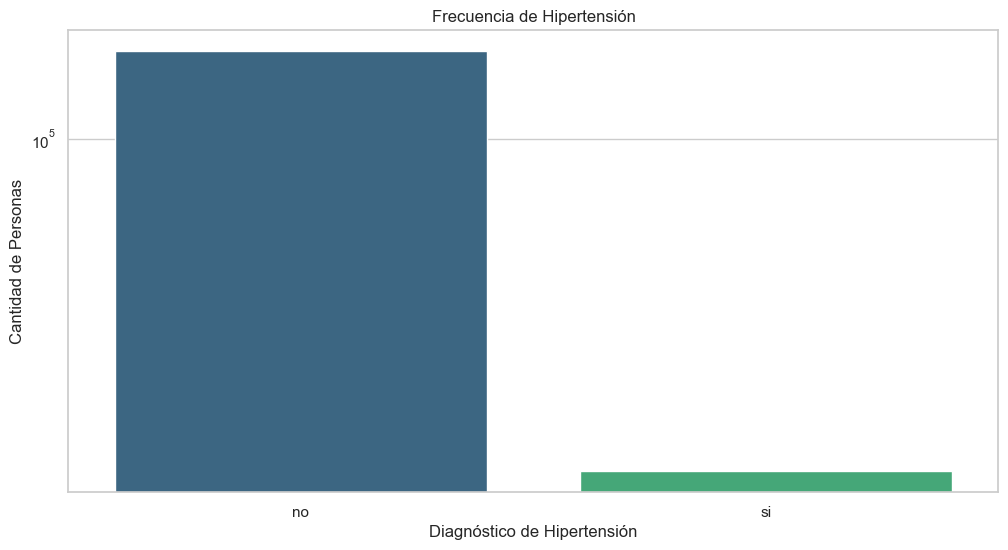

In [546]:
# Gráfico de barras: Frecuencia de hipertensión (Sí/No)
plt.figure(figsize=(12, 6))
sns.countplot(data=salud, x="diagnostico_hipertension", palette="viridis")
plt.title("Frecuencia de Hipertensión")
plt.xlabel("Diagnóstico de Hipertensión")
plt.ylabel("Cantidad de Personas")
plt.yscale("log")
plt.show()

In [233]:
print(salud.columns)

Index(['anio', 'id_hogar', 'conglomerado', 'vivienda', 'hogar', 'num_persona',
       'cod_resultado', 'cod_persona', 'sexo', 'edad', 'asistio_escuela',
       'nivel_aprobado', 'seguro_salud', 'institucion_seguro',
       'diagnostico_hipertension', 'fuma_diario', 'alcohol_30d',
       'dias_jugo_unidad', 'dias_jugo', 'fumo_30d', 'peso_kg', 'talla_cm',
       'resultado_antropometria', 'presion_sis_1', 'presion_dia_1',
       'presion_sis_2', 'presion_dia_2', 'resultado_presion',
       'perimetro_abdominal_cm', 'resultado_perimetro_abd', 'dominio',
       'region', 'area_residencia', 'lugar_residencia', 'codigo_ubicacion_geo',
       'num_conglomerado', 'codigo_centro_poblado', 'nombre_centro_poblado',
       'longitud', 'latitud', 'imc', 'categoria_imc', 'imc_original',
       'excluir', 'presion_sis_promedio', 'presion_dia_promedio',
       'categoria_presion'],
      dtype='object')


#### fuma_diario (no ingresa)

In [234]:
salud["fuma_diario"] = salud["fuma_diario"].fillna("Desconocido")
print(salud["fuma_diario"].unique())

['Desconocido' 'no' 'si']


In [235]:
print(salud["fuma_diario"].value_counts(normalize=True))

fuma_diario
Desconocido    0.919996
no             0.069394
si             0.010610
Name: proportion, dtype: float64


#### fumo_30d (no ingresa)

In [237]:
salud["fumo_30d"] = salud["fumo_30d"].fillna("Desconocido")
print(salud["fumo_30d"].unique())

['Desconocido' 'si' 'no' 'no_sabe_no_recuerda']


In [238]:
print(salud["fumo_30d"].value_counts())

fumo_30d
Desconocido            147524
si                      13784
no                      10976
no_sabe_no_recuerda         8
Name: count, dtype: int64


#### alcohol_30d (no ingresa)

In [240]:
salud["alcohol_30d"] = salud["alcohol_30d"].fillna("Desconocido")
print(salud["alcohol_30d"].unique())

['Desconocido' 'si' 'no' 'no_sabe_no_recuerda']


In [241]:
print(salud["alcohol_30d"].value_counts(normalize=True))

alcohol_30d
Desconocido            0.401475
no                     0.321623
si                     0.276798
no_sabe_no_recuerda    0.000104
Name: proportion, dtype: float64


In [547]:
# número de valores faltants por columna en salud
print(salud.isna().sum())


anio                             0
id_hogar                         0
conglomerado                     0
vivienda                         0
hogar                            0
num_persona                      0
cod_resultado                15546
cod_persona                      0
sexo                             0
edad                             0
asistio_escuela              25204
nivel_aprobado               31583
seguro_salud                 25204
institucion_seguro               0
diagnostico_hipertension         0
fuma_diario                 164662
alcohol_30d                  79146
dias_jugo_unidad             25213
dias_jugo                        0
fumo_30d                    153992
peso_kg                          0
talla_cm                         0
resultado_antropometria      31639
presion_sis_1                    0
presion_dia_1                    0
presion_sis_2                    0
presion_dia_2                    0
resultado_presion            33402
perimetro_abdominal_

In [53]:
# descargar el archivo salud
salud.to_csv("salud.csv", index=False)

## Instrucción

### asistio_escuela

In [244]:
salud['asistio_escuela'] = salud['asistio_escuela'].fillna("Desconocido")
print(salud['asistio_escuela'].unique())

['si' 'Desconocido' 'no']


In [245]:
print(salud['asistio_escuela'].value_counts(normalize=True))

asistio_escuela
si             0.906879
Desconocido    0.056056
no             0.037065
Name: proportion, dtype: float64


### nivel_aprobado

In [246]:
salud["nivel_aprobado"] = salud["nivel_aprobado"].fillna("Desconocido")
print(salud["nivel_aprobado"].unique())

['superior_universitaria' 'superior_no_universitaria' 'primaria'
 'Desconocido' 'secundaria' 'postgrado' 'inicial_preescolar']


In [247]:
print(salud["nivel_aprobado"].value_counts(normalize=True))

nivel_aprobado
secundaria                   0.426619
primaria                     0.211159
superior_no_universitaria    0.139356
superior_universitaria       0.116343
Desconocido                  0.093138
postgrado                    0.011637
inicial_preescolar           0.001747
Name: proportion, dtype: float64


In [248]:
#calcular el promedio de los valores de nivel_aprobado

## VARIABLES

### Data educación

In [249]:
# categoria_nivel_dominio = salud.groupby(['dominio', 'anio', 'nivel_aprobado']).agg(
#     cantidad_personas=('id_hogar', 'count'),
# ).reset_index()

total_personas = salud.groupby(["dominio", "anio"]).agg(
    total_encuestados=("id_hogar", "count")
).reset_index()

In [250]:
# display(categoria_nivel_dominio)

In [251]:
# df_final_nivel = categoria_nivel_dominio.merge(total_personas, on=["dominio", "anio"], how="left")
# df_final_nivel["porcentaje_nivel"] = df_final_nivel["cantidad_personas"] / df_final_nivel["total_encuestados"] * 100

# display(df_final_nivel)

In [252]:
categoria_educacion_dominio = salud.groupby(['dominio', 'anio', 'asistio_escuela']).agg(
    cantidad_personas=('id_hogar', 'count')
    ).reset_index()

In [253]:
df_educacion = categoria_educacion_dominio[categoria_educacion_dominio["asistio_escuela"] == "si"].copy()
display(df_educacion)

,dominio,anio,asistio_escuela,cantidad_personas
2,amazonas,2019,si,1284
5,amazonas,2020,si,1308
8,amazonas,2021,si,1288
11,amazonas,2022,si,1279
14,amazonas,2023,si,1270
...,...,...,...,...
362,ucayali,2019,si,1196
365,ucayali,2020,si,1196
368,ucayali,2021,si,1194
371,ucayali,2022,si,1205


### Data Obesidad

In [254]:
categoria_imc_dominio = salud.groupby(["dominio", "anio", "categoria_imc"]).agg(
    cantidad_personas=("id_hogar", "count"),
    imc_promedio=("imc", "mean"),  # Promedio de IMC
    perimetro_abdominal_promedio=("perimetro_abdominal_cm", "mean")  # Promedio de perimetro
).reset_index()

In [255]:
df_obesidad = categoria_imc_dominio[categoria_imc_dominio['categoria_imc'].str.contains("Obesidad")].copy()
display(df_obesidad)

,dominio,anio,categoria_imc,cantidad_personas,imc_promedio,perimetro_abdominal_promedio
1,amazonas,2019,Obesidad Clase I,159,32.033522,103.235220
2,amazonas,2019,Obesidad Clase II,29,37.068207,111.341379
3,amazonas,2019,Obesidad Clase III,62,42.075228,121.604839
8,amazonas,2020,Obesidad Clase I,118,32.065210,103.172034
9,amazonas,2020,Obesidad Clase II,29,36.621301,111.227586
...,...,...,...,...,...,...
863,ucayali,2022,Obesidad Clase II,67,37.060818,109.871642
864,ucayali,2022,Obesidad Clase III,33,43.940564,118.872727
869,ucayali,2023,Obesidad Clase I,223,31.913731,98.578475
870,ucayali,2023,Obesidad Clase II,60,36.922670,108.001667


In [256]:
df_final_obe = df_obesidad.merge(total_personas, on=["dominio", "anio"], how="left")
df_final_obe["porcentaje_obesidad"] = (df_final_obe["cantidad_personas"] / df_final_obe["total_encuestados"]) * 100

df_final_obe = df_final_obe[
    ["dominio", "anio", "categoria_imc", "cantidad_personas", 
     "total_encuestados", "porcentaje_obesidad", 
     "imc_promedio", "perimetro_abdominal_promedio"]
]
display(df_final_obe)


,dominio,anio,categoria_imc,cantidad_personas,total_encuestados,porcentaje_obesidad,imc_promedio,perimetro_abdominal_promedio
0,amazonas,2019,Obesidad Clase I,159,1409,11.284599,32.033522,103.235220
1,amazonas,2019,Obesidad Clase II,29,1409,2.058197,37.068207,111.341379
2,amazonas,2019,Obesidad Clase III,62,1409,4.400284,42.075228,121.604839
3,amazonas,2020,Obesidad Clase I,118,1427,8.269096,32.065210,103.172034
4,amazonas,2020,Obesidad Clase II,29,1427,2.032235,36.621301,111.227586
...,...,...,...,...,...,...,...,...
370,ucayali,2022,Obesidad Clase II,67,1247,5.372895,37.060818,109.871642
371,ucayali,2022,Obesidad Clase III,33,1247,2.646351,43.940564,118.872727
372,ucayali,2023,Obesidad Clase I,223,1242,17.954911,31.913731,98.578475
373,ucayali,2023,Obesidad Clase II,60,1242,4.830918,36.922670,108.001667


In [257]:
# Filtrar solo las categorías de obesidad
df_obesidad_filtered = df_final_obe[df_final_obe["categoria_imc"].str.contains("Obesidad")]

# Agrupar por dominio y año y calcular los promedios
df_obesidad_resumen = df_obesidad_filtered.groupby(["dominio", "anio"]).agg(
    cantidad_personas=("cantidad_personas", "sum"),
    total_encuestados=("total_encuestados", "first"),  
    porcentaje_obesidad=("porcentaje_obesidad", "mean"),
    imc_promedio=("imc_promedio", "mean"),
    perimetro_abdominal_promedio=("perimetro_abdominal_promedio", "mean")
).reset_index()

display(df_obesidad_resumen)


,dominio,anio,cantidad_personas,total_encuestados,porcentaje_obesidad,imc_promedio,perimetro_abdominal_promedio
0,amazonas,2019,250,1409,5.914360,37.058985,112.060479
1,amazonas,2020,647,1427,15.113291,36.720748,112.157273
2,amazonas,2021,284,1387,6.825282,36.858170,111.224641
3,amazonas,2022,263,1391,6.302420,37.340276,111.999617
4,amazonas,2023,267,1393,6.389088,36.659762,111.234350
...,...,...,...,...,...,...,...
120,ucayali,2019,312,1245,8.353414,37.332667,111.686412
121,ucayali,2020,558,1236,15.048544,37.178873,110.246673
122,ucayali,2021,330,1240,8.870968,37.469910,110.025333
123,ucayali,2022,337,1247,9.008287,37.615913,109.640387


### Data Hipertensión

In [258]:
categoria_hipertension_dominio = salud.groupby(["dominio", "anio", "categoria_presion"]).agg(
    cantidad_personas=("id_hogar", "count"),
    presion_sistolica_promedio=("presion_sis_promedio", "mean"),
    presion_diastolica_promedio=("presion_dia_promedio", "mean")
).reset_index()

In [259]:
df_hipertension = categoria_hipertension_dominio[categoria_hipertension_dominio['categoria_presion'].str.contains("Hipertensión")].copy()
# display(df_hipertension)

In [260]:
df_final_hip = df_hipertension.merge(total_personas, on=["dominio", "anio"], how="left")
df_final_hip["porcentaje_hipertension"] = (df_final_hip["cantidad_personas"] / df_final_hip["total_encuestados"]) * 100

df_final_hip = df_final_hip[
    ["dominio", "anio", "categoria_presion", "cantidad_personas", 
     "total_encuestados", "porcentaje_hipertension", 
     "presion_sistolica_promedio", "presion_diastolica_promedio"]
]

display(df_final_hip)

,dominio,anio,categoria_presion,cantidad_personas,total_encuestados,porcentaje_hipertension,presion_sistolica_promedio,presion_diastolica_promedio
0,amazonas,2019,Crisis Hipertensiva (Hipertensión Etapa 3),19,1409,1.348474,192.131579,89.960526
1,amazonas,2019,Hipertensión Etapa 1,239,1409,16.962385,130.100418,78.939331
2,amazonas,2019,Hipertensión Etapa 2,152,1409,10.787793,150.299342,82.503289
3,amazonas,2020,Crisis Hipertensiva (Hipertensión Etapa 3),78,1427,5.466013,191.621795,95.439103
4,amazonas,2020,Hipertensión Etapa 1,144,1427,10.091100,130.847222,79.670139
...,...,...,...,...,...,...,...,...
370,ucayali,2022,Hipertensión Etapa 1,213,1247,17.080994,125.969484,80.183099
371,ucayali,2022,Hipertensión Etapa 2,51,1247,4.089816,150.843137,89.529412
372,ucayali,2023,Crisis Hipertensiva (Hipertensión Etapa 3),1,1242,0.080515,190.500000,117.000000
373,ucayali,2023,Hipertensión Etapa 1,215,1242,17.310789,125.969767,80.676744


In [261]:
#filtrar sobre las categorías de hipertensión
df_hipertension_filtered = df_final_hip[df_final_hip["categoria_presion"].str.contains("Hipertensión")]

#agrupar por dominio y año
df_hipertension_resumen = df_hipertension_filtered.groupby(["dominio", "anio"]).agg(
    cantidad_personas=("cantidad_personas", "sum"),
    total_encuestados=("total_encuestados", "first"),
    porcentaje_hipertension=("porcentaje_hipertension", "mean"),
    presion_sistolica_promedio=("presion_sistolica_promedio", "mean"),
    presion_diastolica_promedio=("presion_diastolica_promedio", "mean")
).reset_index()

display(df_hipertension_resumen)

,dominio,anio,cantidad_personas,total_encuestados,porcentaje_hipertension,presion_sistolica_promedio,presion_diastolica_promedio
0,amazonas,2019,410,1409,9.699551,157.510446,83.801049
1,amazonas,2020,306,1427,7.147863,158.241656,84.796334
2,amazonas,2021,428,1387,10.285989,157.361029,86.815328
3,amazonas,2022,406,1391,9.729212,155.751342,91.923674
4,amazonas,2023,349,1393,8.351280,155.956175,91.599000
...,...,...,...,...,...,...,...
120,ucayali,2019,222,1245,5.943775,162.360545,80.127854
121,ucayali,2020,201,1236,5.420712,157.561203,85.124448
122,ucayali,2021,255,1240,6.854839,155.437373,87.705329
123,ucayali,2022,266,1247,7.110398,157.020874,89.529170


### Data unión

In [262]:
categoria_union_dominio = salud.groupby(["dominio", "anio","categoria_imc", "categoria_presion"]).agg(
    cantidad_personas=("id_hogar", "count"),
    
    presion_sistolica_promedio=("presion_sis_promedio", "mean"),
    presion_diastolica_promedio=("presion_dia_promedio", "mean"),
    imc_promedio=("imc", "mean"),  # Promedio de IMC
    perimetro_abdominal_promedio=("perimetro_abdominal_cm", "mean")  # Promedio de perimetro
).reset_index()

In [263]:
df_union = categoria_union_dominio[
    (categoria_union_dominio['categoria_imc'].str.contains("Obesidad", na=False)) &
    (categoria_union_dominio['categoria_presion'].str.contains("Hipertensión", na=False))
].copy()
display(df_union)

,dominio,anio,categoria_imc,categoria_presion,cantidad_personas,presion_sistolica_promedio,presion_diastolica_promedio,imc_promedio,perimetro_abdominal_promedio
3,amazonas,2019,Obesidad Clase I,Crisis Hipertensiva (Hipertensión Etapa 3),2,192.250000,108.750000,31.996577,104.700000
5,amazonas,2019,Obesidad Clase I,Hipertensión Etapa 1,46,128.858696,79.684783,32.151868,103.582609
6,amazonas,2019,Obesidad Clase I,Hipertensión Etapa 2,16,151.406250,84.625000,32.433080,106.056250
9,amazonas,2019,Obesidad Clase II,Hipertensión Etapa 1,8,130.812500,80.625000,36.748721,113.187500
10,amazonas,2019,Obesidad Clase II,Hipertensión Etapa 2,6,151.666667,81.750000,36.388453,113.550000
...,...,...,...,...,...,...,...,...,...
3620,ucayali,2023,Obesidad Clase I,Hipertensión Etapa 2,13,156.884615,94.423077,31.360646,100.600000
3623,ucayali,2023,Obesidad Clase II,Hipertensión Etapa 1,20,128.150000,81.425000,37.083440,108.650000
3624,ucayali,2023,Obesidad Clase II,Hipertensión Etapa 2,7,149.357143,94.642857,36.634580,111.171429
3626,ucayali,2023,Obesidad Clase III,Hipertensión Etapa 1,6,124.166667,82.083333,43.361875,116.050000


In [264]:
df_final_union = df_union.merge(total_personas, on=["dominio", "anio"], how="left")

df_final_union["porcentaje_obesidad_hipertension"] = (df_final_union["cantidad_personas"] / df_final_union["total_encuestados"]) * 100


df_final_union = df_final_union[
    ["dominio", "anio", "categoria_imc","categoria_presion", "cantidad_personas", 
     "total_encuestados",  "porcentaje_obesidad_hipertension", 
     "imc_promedio", "perimetro_abdominal_promedio", 
     "presion_sistolica_promedio", "presion_diastolica_promedio"]
]

display(df_final_union)

,dominio,anio,categoria_imc,categoria_presion,cantidad_personas,total_encuestados,porcentaje_obesidad_hipertension,imc_promedio,perimetro_abdominal_promedio,presion_sistolica_promedio,presion_diastolica_promedio
0,amazonas,2019,Obesidad Clase I,Crisis Hipertensiva (Hipertensión Etapa 3),2,1409,0.141945,31.996577,104.700000,192.250000,108.750000
1,amazonas,2019,Obesidad Clase I,Hipertensión Etapa 1,46,1409,3.264727,32.151868,103.582609,128.858696,79.684783
2,amazonas,2019,Obesidad Clase I,Hipertensión Etapa 2,16,1409,1.135557,32.433080,106.056250,151.406250,84.625000
3,amazonas,2019,Obesidad Clase II,Hipertensión Etapa 1,8,1409,0.567779,36.748721,113.187500,130.812500,80.625000
4,amazonas,2019,Obesidad Clase II,Hipertensión Etapa 2,6,1409,0.425834,36.388453,113.550000,151.666667,81.750000
...,...,...,...,...,...,...,...,...,...,...,...
895,ucayali,2023,Obesidad Clase I,Hipertensión Etapa 2,13,1242,1.046699,31.360646,100.600000,156.884615,94.423077
896,ucayali,2023,Obesidad Clase II,Hipertensión Etapa 1,20,1242,1.610306,37.083440,108.650000,128.150000,81.425000
897,ucayali,2023,Obesidad Clase II,Hipertensión Etapa 2,7,1242,0.563607,36.634580,111.171429,149.357143,94.642857
898,ucayali,2023,Obesidad Clase III,Hipertensión Etapa 1,6,1242,0.483092,43.361875,116.050000,124.166667,82.083333


In [265]:
#filtrar sobre las categorías de union
df_union_filtered = df_final_union[
    (df_final_union['categoria_imc'].str.contains("Obesidad", na=False)) &
    (df_final_union['categoria_presion'].str.contains("Hipertensión", na=False))
].copy()

#agrupar por dominio y año
df_union_resumen = df_union_filtered.groupby(["dominio", "anio"]).agg(
    cantidad_personas=("cantidad_personas", "sum"),
    total_encuestados=("total_encuestados", "first"),
    imc_promedio=("imc_promedio", "mean"),
    perimetro_abdominal_promedio=("perimetro_abdominal_promedio", "mean"),
    presion_sistolica_promedio=("presion_sistolica_promedio", "mean"),
    presion_diastolica_promedio=("presion_diastolica_promedio", "mean"),
    porcentaje_obesidad_hipertension=("porcentaje_obesidad_hipertension", "mean")
).reset_index()

display(df_union_resumen)

,dominio,anio,cantidad_personas,total_encuestados,imc_promedio,perimetro_abdominal_promedio,presion_sistolica_promedio,presion_diastolica_promedio,porcentaje_obesidad_hipertension
0,amazonas,2019,82,1409,36.299653,110.810908,145.106302,86.776398,0.831390
1,amazonas,2020,57,1427,34.450170,108.845723,155.441248,88.562390,0.665732
2,amazonas,2021,110,1387,36.241030,110.263998,145.390929,87.357560,1.132969
3,amazonas,2022,88,1391,35.617623,111.187079,146.908670,92.647096,1.054397
4,amazonas,2023,83,1393,36.446143,111.254356,144.692232,88.854048,0.851195
...,...,...,...,...,...,...,...,...,...
120,ucayali,2019,76,1245,36.818005,110.384082,147.582080,80.749969,0.872060
121,ucayali,2020,64,1236,37.338999,111.282568,139.781916,80.613311,0.862999
122,ucayali,2021,89,1240,37.168640,111.665303,153.823227,90.564874,0.797491
123,ucayali,2022,93,1247,37.140156,108.078224,138.328776,88.171618,1.242983


### Data departamentos

In [266]:
import geopandas as gpd
import fiona
import os
import fiona
print(fiona.__version__)
print(dir(fiona))

1.10.1
['BytesCollection', 'Collection', 'Env', 'ExitStack', 'FIELD_TYPES_MAP', 'Feature', 'FionaDeprecationWarning', 'Geometry', 'MemoryFile', 'NAMED_FIELD_TYPES', 'Path', 'Properties', '_ParsedPath', '_UnparsedPath', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__gdal_version__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_bounds', '_env', '_err', '_geometry', '_listdir', '_listlayers', '_opener_registration', '_parse_path', '_path', '_remove', '_remove_layer', '_show_versions', '_vsi_path', '_vsiopener', '_whl_dir', 'bounds', 'calc_gdal_version_num', 'collection', 'compat', 'crs', 'driver_count', 'drivers', 'drvsupport', 'ensure_env_with_credentials', 'enums', 'env', 'errors', 'gdal_version', 'get_gdal_release_name', 'get_gdal_version_num', 'get_gdal_version_tuple', 'glob', 'io', 'listdir', 'listlayers', 'log', 'logging', 'logutils', 'meta', 'model', 'ogrext', 'open', 'os', 'p', 'platform', 'prop_type', 'prop_width', 'remove'

In [267]:
shapefile_path = r"..\Departamental INEI 2023 geogpsperu SuyoPomalia\Departamental INEI 2023 geogpsperu SuyoPomalia.shp"
departamentos = gpd.read_file(shapefile_path)

departamentos_plus = pd.read_csv(r"..\regional_df.csv")

# Quitar tildes de region_provincia_distrito
departamentos_plus["region_provincia_distrito"] = departamentos_plus["region_provincia_distrito"].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

print(departamentos.head(1))
display(departamentos_plus.head())

departamentos = departamentos.merge(departamentos_plus, how="left", left_on="DEPARTAMEN", right_on="region_provincia_distrito")
print(departamentos.head(1))

  CCDD DEPARTAMEN  OBJECTID  ESRI_OID  \
0   01   AMAZONAS       1.0       1.0   

                                            geometry  
0  POLYGON ((-77.81399 -2.99278, -77.81483 -2.995...  


,ubigeo,region_provincia_distrito,poblacion_total_2007,poblacion_total_2017,poblacion_total_2020,poblacion_menores_uno_2017,poblacion_mayores_80_2020,poblacion_discapacidad_2020,superficie_km2,densidad_2020,...,indice_desarrollo_humano_2019,porcentaje_poblacion_pobreza_total,numero_habitantes_pobreza_total,porcentaje_poblacion_pobreza_extrema,numero_habitantes_pobreza_extrema,poblacion_ocupada_2007,poblacion_ocupada_2017,devengado_per_capita_actividad_2020,devengado_per_capita_inversion_2020,devengado_per_capita_total_2020
0,150000,LIMA,8730820,10135009,11261067,137218,217672,88625,34823.52,323.375322,...,0.707336,26.25,2.956030e+06,3.05,343462.5435,3625326,4.873073e+06,6923.735936,488.735054,7412.470989
1,10000,AMAZONAS,406087,417365,472993,8043,7743,7826,39249.13,12.051044,...,0.417736,32.95,1.558512e+05,7.30,34528.4890,124320,1.427014e+05,3919.830013,1561.378837,5481.208850
2,60000,CAJAMARCA,1476708,1427527,1603521,24296,34202,14891,33304.32,48.147538,...,0.425118,43.65,6.999369e+05,12.95,207655.9695,439480,4.943605e+05,3413.331404,774.510604,4187.842009
3,130000,LA LIBERTAD,1682213,1888972,2054619,32610,38674,12707,25495.42,80.587768,...,0.548224,32.95,6.769970e+05,7.30,149987.1870,567300,7.372602e+05,2516.544411,655.059079,3171.603489
4,140000,LAMBAYEQUE,1174519,1244821,1393148,20923,26935,8254,14461.52,96.334825,...,0.534252,17.30,2.410146e+05,0.55,7662.3140,377864,4.792206e+05,2541.591065,443.446746,2985.037811


  CCDD DEPARTAMEN  OBJECTID  ESRI_OID  \
0   01   AMAZONAS       1.0       1.0   

                                            geometry  ubigeo  \
0  POLYGON ((-77.81399 -2.99278, -77.81483 -2.995...   10000   

  region_provincia_distrito  poblacion_total_2007  poblacion_total_2017  \
0                  AMAZONAS                406087                417365   

   poblacion_total_2020  ...  indice_desarrollo_humano_2019  \
0                472993  ...                       0.417736   

   porcentaje_poblacion_pobreza_total  numero_habitantes_pobreza_total  \
0                               32.95                      155851.1935   

   porcentaje_poblacion_pobreza_extrema  numero_habitantes_pobreza_extrema  \
0                                   7.3                          34528.489   

  poblacion_ocupada_2007  poblacion_ocupada_2017  \
0                 124320           142701.360234   

   devengado_per_capita_actividad_2020  devengado_per_capita_inversion_2020  \
0                   

In [268]:
#agrupar por anio  dominio
dd_departamentos = salud.groupby(["anio", "dominio"]).agg({"id_hogar": "count"}).reset_index()

print("Nombre en dd_departamentos:", dd_departamentos["dominio"].unique())

Nombre en dd_departamentos: ['amazonas' 'ancash' 'apurimac' 'arequipa' 'ayacucho' 'cajamarca' 'callao'
 'cusco' 'huancavelica' 'huanuco' 'ica' 'junin' 'la_libertad' 'lambayeque'
 'lima' 'loreto' 'madre_de_dios' 'moquegua' 'pasco' 'piura' 'puno'
 'san_martin' 'tacna' 'tumbes' 'ucayali']


In [269]:
dd_departamentos["dominio"] = dd_departamentos["dominio"].str.upper().str.replace("_", " ")


# Verificar que los cambios se aplicaron correctamente
print("Nombres después del reemplazo:")
print(sorted(dd_departamentos["dominio"].unique()))

Nombres después del reemplazo:
['AMAZONAS', 'ANCASH', 'APURIMAC', 'AREQUIPA', 'AYACUCHO', 'CAJAMARCA', 'CALLAO', 'CUSCO', 'HUANCAVELICA', 'HUANUCO', 'ICA', 'JUNIN', 'LA LIBERTAD', 'LAMBAYEQUE', 'LIMA', 'LORETO', 'MADRE DE DIOS', 'MOQUEGUA', 'PASCO', 'PIURA', 'PUNO', 'SAN MARTIN', 'TACNA', 'TUMBES', 'UCAYALI']


In [270]:
print("Valores únicos en DEPARTAMEN:")
print(departamentos["DEPARTAMEN"].unique())

print("Valores únicos en dominio:")
print(dd_departamentos["dominio"].unique())


Valores únicos en DEPARTAMEN:
['AMAZONAS' 'ANCASH' 'APURIMAC' 'AREQUIPA' 'AYACUCHO' 'CAJAMARCA' 'CALLAO'
 'CUSCO' 'HUANCAVELICA' 'HUANUCO' 'ICA' 'JUNIN' 'LA LIBERTAD' 'LAMBAYEQUE'
 'LIMA' 'LORETO' 'MADRE DE DIOS' 'MOQUEGUA' 'PASCO' 'PIURA' 'PUNO'
 'SAN MARTIN' 'TACNA' 'TUMBES' 'UCAYALI']
Valores únicos en dominio:
['AMAZONAS' 'ANCASH' 'APURIMAC' 'AREQUIPA' 'AYACUCHO' 'CAJAMARCA' 'CALLAO'
 'CUSCO' 'HUANCAVELICA' 'HUANUCO' 'ICA' 'JUNIN' 'LA LIBERTAD' 'LAMBAYEQUE'
 'LIMA' 'LORETO' 'MADRE DE DIOS' 'MOQUEGUA' 'PASCO' 'PIURA' 'PUNO'
 'SAN MARTIN' 'TACNA' 'TUMBES' 'UCAYALI']


In [271]:
departamentos = departamentos.merge(dd_departamentos, left_on='DEPARTAMEN', right_on='dominio')
departamentos.drop(columns=['dominio'], inplace=True)
# display(departamentos)

In [272]:
# Revisar los nombres de departamentos en ambos DataFrames
print("Nombre en departamentos:", departamentos["DEPARTAMEN"].unique())

Nombre en departamentos: ['AMAZONAS' 'ANCASH' 'APURIMAC' 'AREQUIPA' 'AYACUCHO' 'CAJAMARCA' 'CALLAO'
 'CUSCO' 'HUANCAVELICA' 'HUANUCO' 'ICA' 'JUNIN' 'LA LIBERTAD' 'LAMBAYEQUE'
 'LIMA' 'LORETO' 'MADRE DE DIOS' 'MOQUEGUA' 'PASCO' 'PIURA' 'PUNO'
 'SAN MARTIN' 'TACNA' 'TUMBES' 'UCAYALI']


### Merge con df_obesidad resumen

In [273]:
mapeo_nombres = {
    "la_libertad": "LA LIBERTAD",
    "madre_de_dios": "MADRE DE DIOS",
    "san_martin": "SAN MARTIN"
}

# Paso 2: Transformar los nombres en df_obesidad_resumen antes de hacer el merge
df_obesidad_resumen["dominio"] = df_obesidad_resumen["dominio"].replace(mapeo_nombres)
df_obesidad_resumen["dominio"] = df_obesidad_resumen["dominio"].str.upper()



In [274]:
# Unir con la población total de cada departamento en 2020 asegurando que no haya duplicados
porcentaje_obesidad_anio = df_obesidad_resumen.merge(departamentos[["DEPARTAMEN", "poblacion_total_2020"]].drop_duplicates(), left_on="dominio", right_on="DEPARTAMEN", how="left")

#calcular la tasa de obesidad por cada 100k habitantes
porcentaje_obesidad_anio["tasa_obesidad_por_100k"] = (porcentaje_obesidad_anio["cantidad_personas"] / porcentaje_obesidad_anio["poblacion_total_2020"]) * 100000

#eliminar columnas innecesarias después del merge
porcentaje_obesidad_anio.drop(columns=["DEPARTAMEN"], inplace=True)

#mostrar resultados únicos por departamento y año
porcentaje_obesidad_anio = porcentaje_obesidad_anio.drop_duplicates(subset=["dominio", "anio"])
display(porcentaje_obesidad_anio)

,dominio,anio,cantidad_personas,total_encuestados,porcentaje_obesidad,imc_promedio,perimetro_abdominal_promedio,poblacion_total_2020,tasa_obesidad_por_100k
0,AMAZONAS,2019,250,1409,5.914360,37.058985,112.060479,472993,52.854905
1,AMAZONAS,2020,647,1427,15.113291,36.720748,112.157273,472993,136.788494
2,AMAZONAS,2021,284,1387,6.825282,36.858170,111.224641,472993,60.043172
3,AMAZONAS,2022,263,1391,6.302420,37.340276,111.999617,472993,55.603360
4,AMAZONAS,2023,267,1393,6.389088,36.659762,111.234350,472993,56.449038
...,...,...,...,...,...,...,...,...,...
120,UCAYALI,2019,312,1245,8.353414,37.332667,111.686412,632861,49.299925
121,UCAYALI,2020,558,1236,15.048544,37.178873,110.246673,632861,88.171020
122,UCAYALI,2021,330,1240,8.870968,37.469910,110.025333,632861,52.144152
123,UCAYALI,2022,337,1247,9.008287,37.615913,109.640387,632861,53.250240


In [275]:
print(df_obesidad_resumen["dominio"].unique())  # Ver qué valores tiene la columna
print("MOQUEGUA" in df_obesidad_resumen["dominio"].values)  # Verificar si existe

['AMAZONAS' 'ANCASH' 'APURIMAC' 'AREQUIPA' 'AYACUCHO' 'CAJAMARCA' 'CALLAO'
 'CUSCO' 'HUANCAVELICA' 'HUANUCO' 'ICA' 'JUNIN' 'LA LIBERTAD' 'LAMBAYEQUE'
 'LIMA' 'LORETO' 'MADRE DE DIOS' 'MOQUEGUA' 'PASCO' 'PIURA' 'PUNO'
 'SAN MARTIN' 'TACNA' 'TUMBES' 'UCAYALI']
True


In [276]:
df_obesidad_resumen["dominio"] = df_obesidad_resumen["dominio"].str.strip()
departamentos["DEPARTAMEN"] = departamentos["DEPARTAMEN"].str.strip()

print(df_obesidad_resumen["dominio"].dtype)
print(departamentos["DEPARTAMEN"].dtype)

object
object


In [277]:
departamentos_mapa = departamentos.merge(porcentaje_obesidad_anio, left_on=["DEPARTAMEN", "anio"], right_on=["dominio", "anio"], how="left")

In [278]:
print(departamentos["DEPARTAMEN"].unique())  # Ver lista de departamentos en el mapa
print("MOQUEGUA" in departamentos["DEPARTAMEN"].values)  # Ver si está incluido

['AMAZONAS' 'ANCASH' 'APURIMAC' 'AREQUIPA' 'AYACUCHO' 'CAJAMARCA' 'CALLAO'
 'CUSCO' 'HUANCAVELICA' 'HUANUCO' 'ICA' 'JUNIN' 'LA LIBERTAD' 'LAMBAYEQUE'
 'LIMA' 'LORETO' 'MADRE DE DIOS' 'MOQUEGUA' 'PASCO' 'PIURA' 'PUNO'
 'SAN MARTIN' 'TACNA' 'TUMBES' 'UCAYALI']
True


#### Mapas de calor

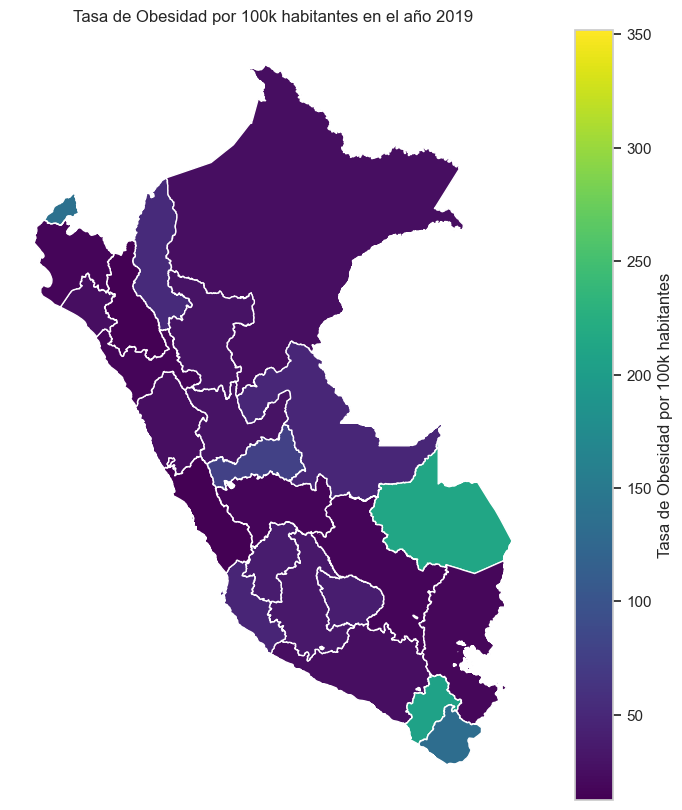

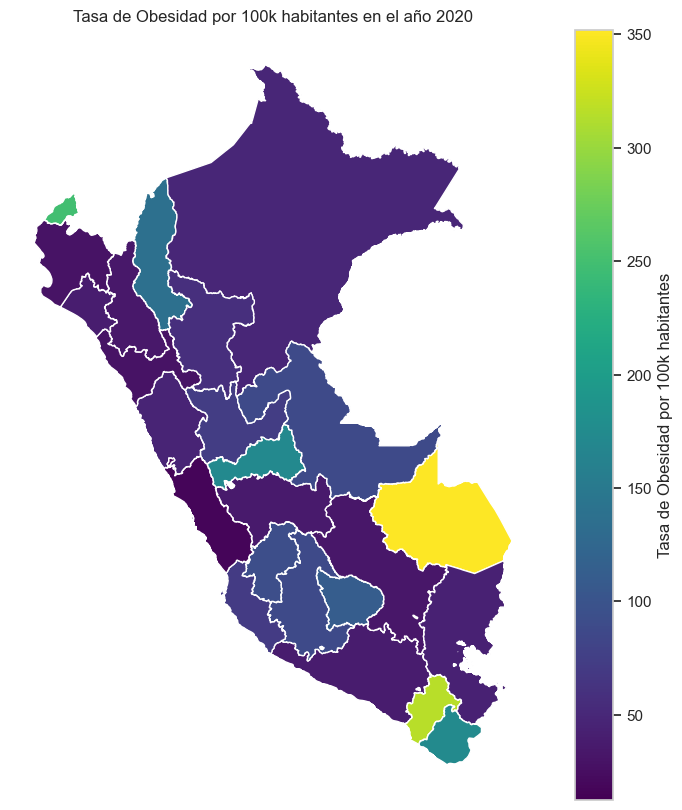

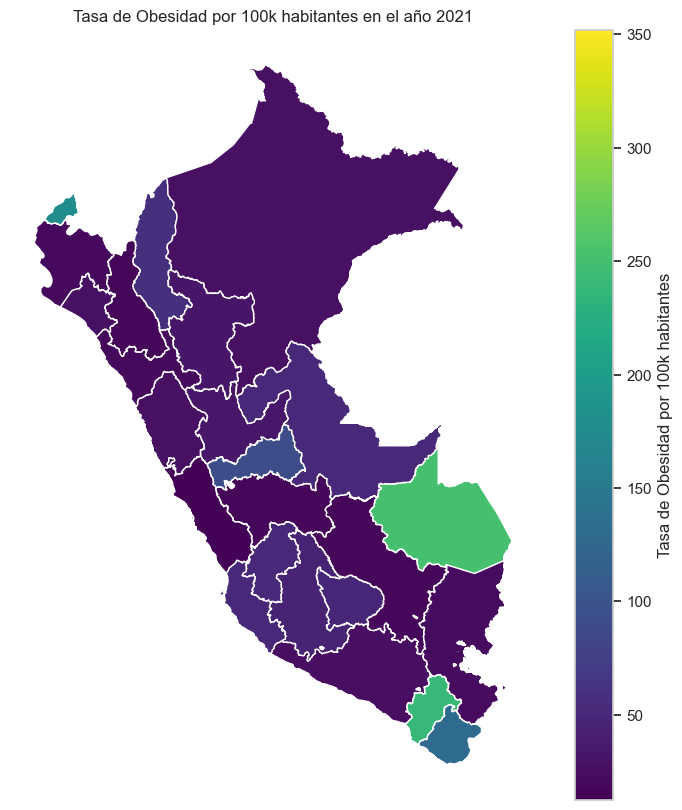

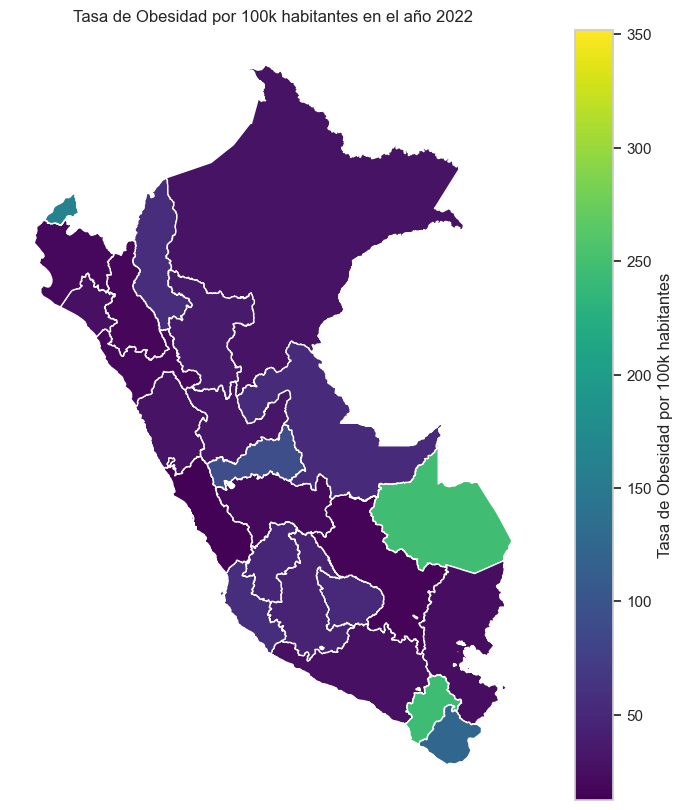

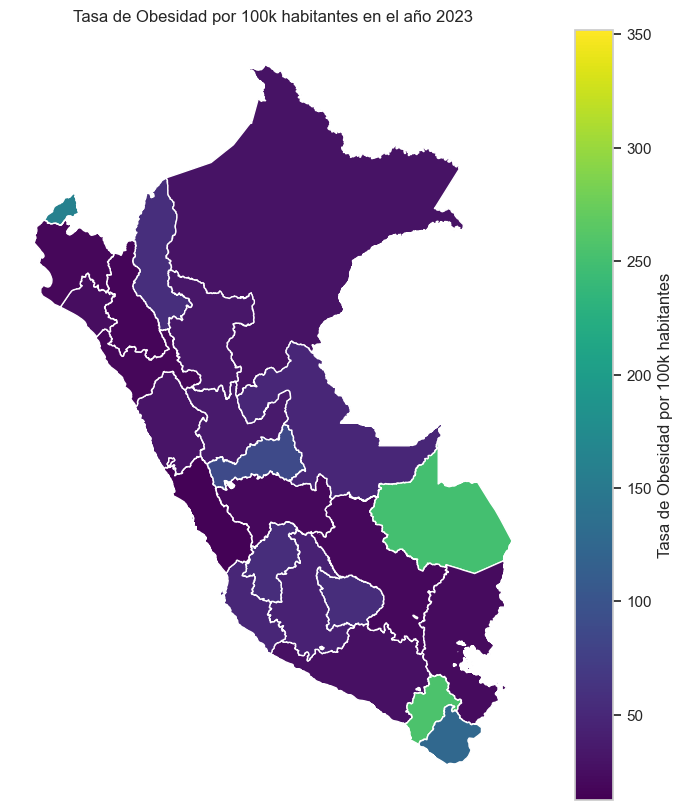

In [279]:
vmin = departamentos_mapa["tasa_obesidad_por_100k"].min()
vmax = departamentos_mapa["tasa_obesidad_por_100k"].max()

for anio in departamentos_mapa["anio"].unique():
    fig, ax = plt.subplots(figsize=(10, 10))
    departamentos_mapa_anio = departamentos_mapa[departamentos_mapa["anio"] == anio]
    
    departamentos_mapa_anio.plot(
        column='tasa_obesidad_por_100k', 
        cmap='viridis',  # Prueba con viridis, plasma o cividis para mejor percepción
        ax=ax, 
        legend=True, 
        legend_kwds={'label': "Tasa de Obesidad por 100k habitantes"},
        vmin=vmin, 
        vmax=vmax  # Fija la escala de colores para evitar distorsión año a año
    )

    ax.set_title(f"Tasa de Obesidad por 100k habitantes en el año {anio}")
    ax.axis('off')
    plt.show()


#### Gráfico de líneas

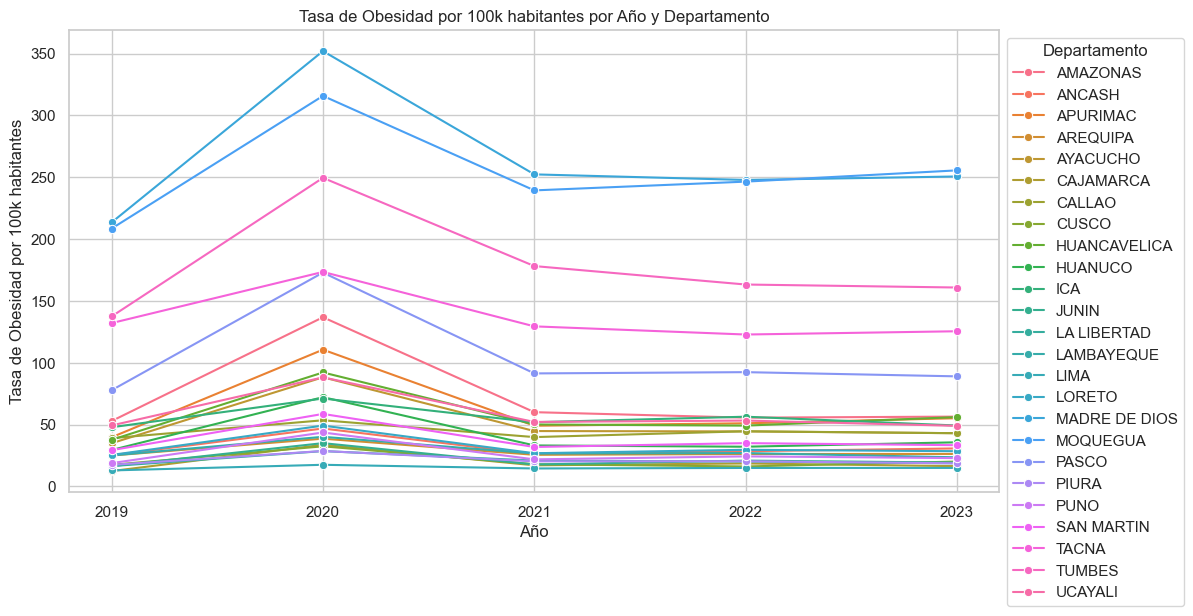

In [280]:
#GRÁFICO DE TENDENCIA
plt.figure(figsize=(12, 6))
sns.lineplot(data=departamentos_mapa, x="anio", y="tasa_obesidad_por_100k", hue="dominio", marker="o")
plt.title("Tasa de Obesidad por 100k habitantes por Año y Departamento")
plt.xlabel("Año")
plt.ylabel("Tasa de Obesidad por 100k habitantes")
plt.legend(title="Departamento", bbox_to_anchor=(1, 1), loc = 'upper left')
plt.grid(True)
plt.xticks(ticks=[2019, 2020, 2021, 2022, 2023], labels=[2019, 2020, 2021, 2022, 2023])
plt.show()

### Merge con indice_educacion

In [281]:
df_educacion["dominio"] = df_educacion["dominio"].replace(mapeo_nombres)
df_educacion["dominio"] = df_educacion["dominio"].str.upper()

In [282]:
porcentaje_educacion_anio = df_educacion.merge(departamentos[["DEPARTAMEN", "poblacion_total_2020"]].drop_duplicates(), left_on="dominio", right_on="DEPARTAMEN", how="left")
porcentaje_educacion_anio["tasa_educacion_por_100k"] = (porcentaje_educacion_anio["cantidad_personas"] / porcentaje_educacion_anio["poblacion_total_2020"]) * 100000
porcentaje_educacion_anio.drop(columns=["DEPARTAMEN"], inplace=True)
porcentaje_educacion_anio = porcentaje_educacion_anio.drop_duplicates(subset=["dominio", "anio", "asistio_escuela"])
display(porcentaje_educacion_anio)

,dominio,anio,asistio_escuela,cantidad_personas,poblacion_total_2020,tasa_educacion_por_100k
0,AMAZONAS,2019,si,1284,472993,271.462791
1,AMAZONAS,2020,si,1308,472993,276.536862
2,AMAZONAS,2021,si,1288,472993,272.308470
3,AMAZONAS,2022,si,1279,472993,270.405693
4,AMAZONAS,2023,si,1270,472993,268.502917
...,...,...,...,...,...,...
120,UCAYALI,2019,si,1196,632861,188.983047
121,UCAYALI,2020,si,1196,632861,188.983047
122,UCAYALI,2021,si,1194,632861,188.667022
123,UCAYALI,2022,si,1205,632861,190.405160


In [283]:
df_educacion["dominio"] = df_educacion["dominio"].str.strip()
departamentos["DEPARTAMEN"] = departamentos["DEPARTAMEN"].str.strip()

print(df_educacion["dominio"].dtype)
print(departamentos["DEPARTAMEN"].dtype)

object
object


#### Mapa de calor

In [284]:
departamentos_mapa_ed = departamentos.merge(porcentaje_educacion_anio, left_on=["DEPARTAMEN", "anio"], right_on=["dominio", "anio"], how="left")

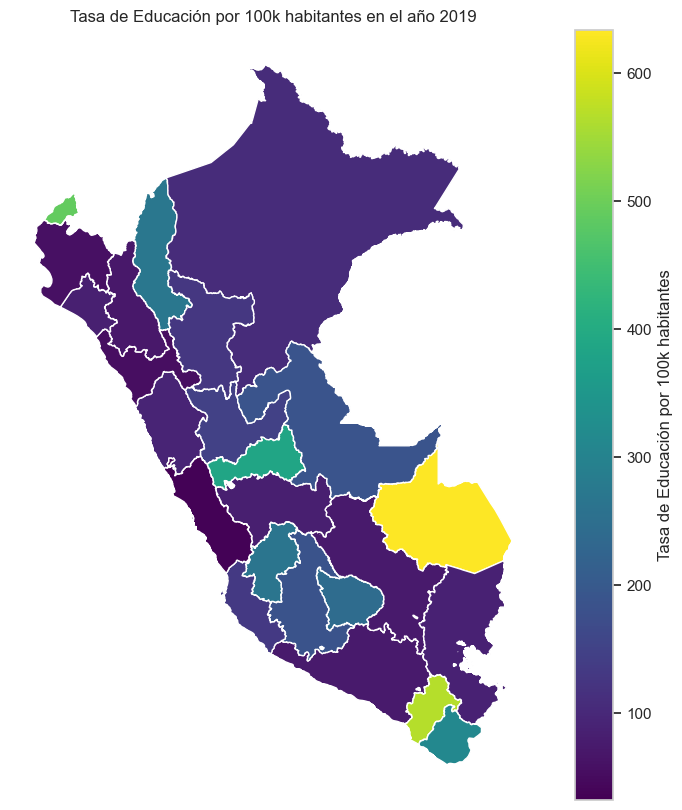

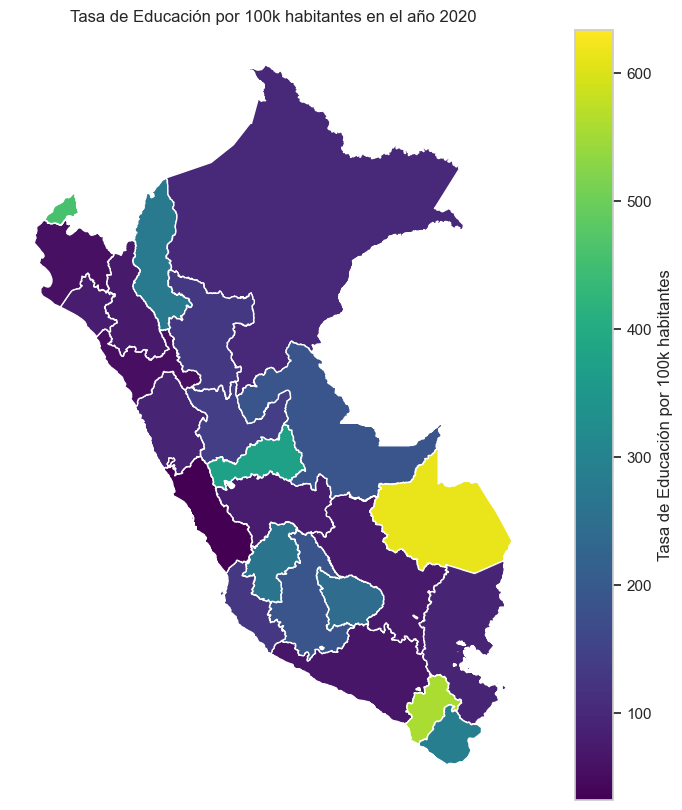

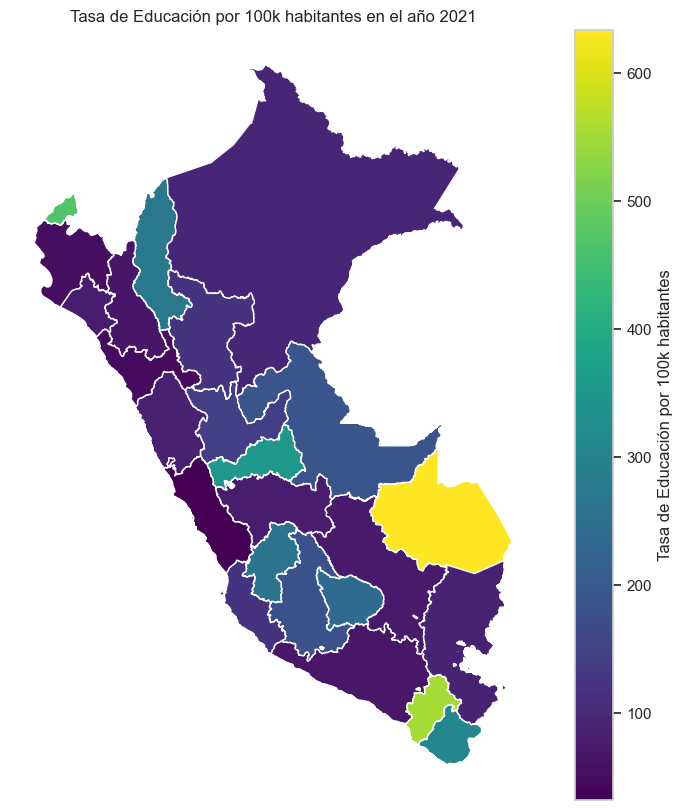

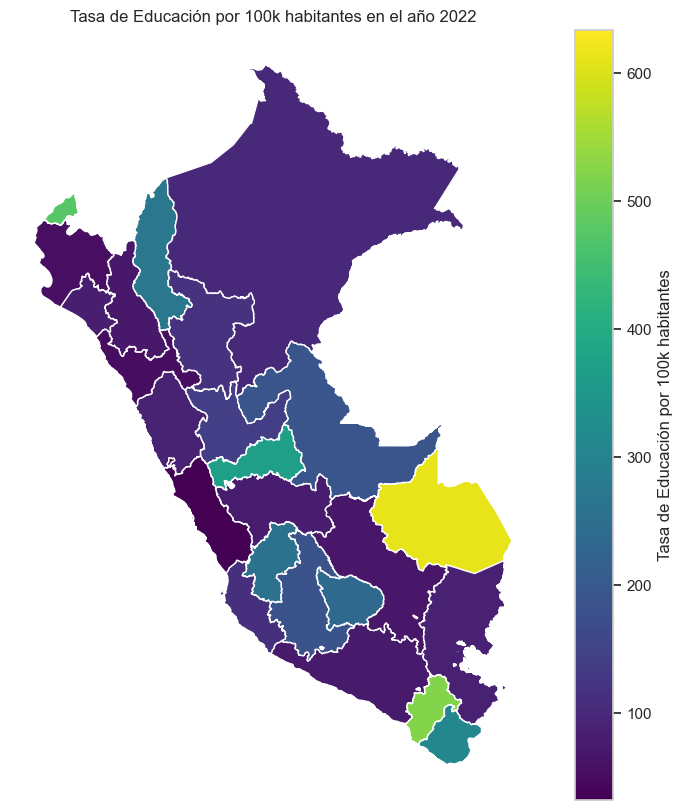

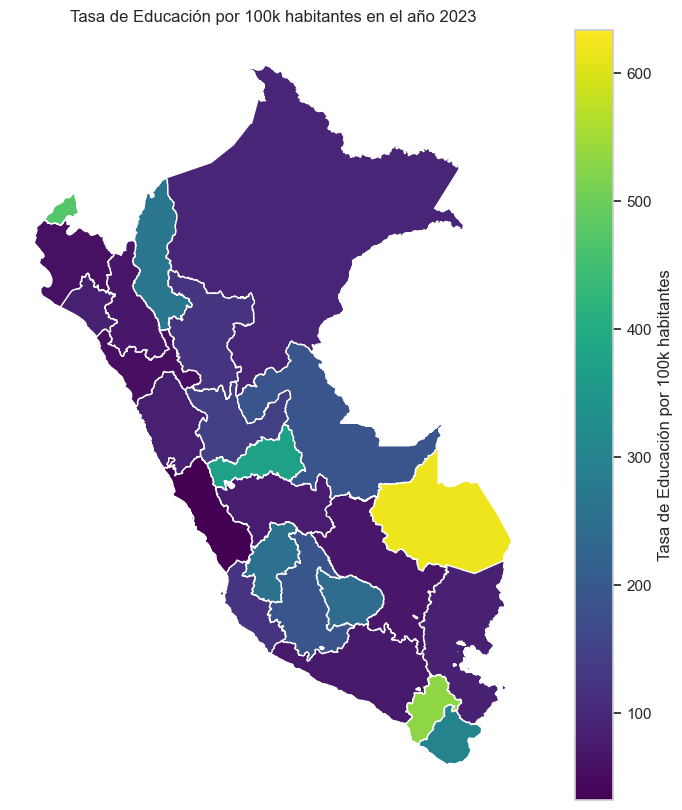

In [286]:
vminEd = departamentos_mapa_ed["tasa_educacion_por_100k"].min()
vmaxEd = departamentos_mapa_ed["tasa_educacion_por_100k"].max()

for anio in departamentos_mapa_ed["anio"].unique():
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    departamentos_mapa_anio = departamentos_mapa_ed[departamentos_mapa_ed["anio"] == anio]
    
    departamentos_mapa_anio.plot(
        column='tasa_educacion_por_100k', 
        cmap='viridis',  # Prueba con viridis, plasma o cividis para mejor percepción
        ax=ax, 
        legend=True, 
        legend_kwds={'label': "Tasa de Educación por 100k habitantes"},
        vmin=vminEd, 
        vmax=vmaxEd  # Fija la escala de colores para evitar distorsión año a año
    )

    ax.set_title(f"Tasa de Educación por 100k habitantes en el año {anio}")
    ax.axis('off')
    plt.show()

#### Gráfico de líneas

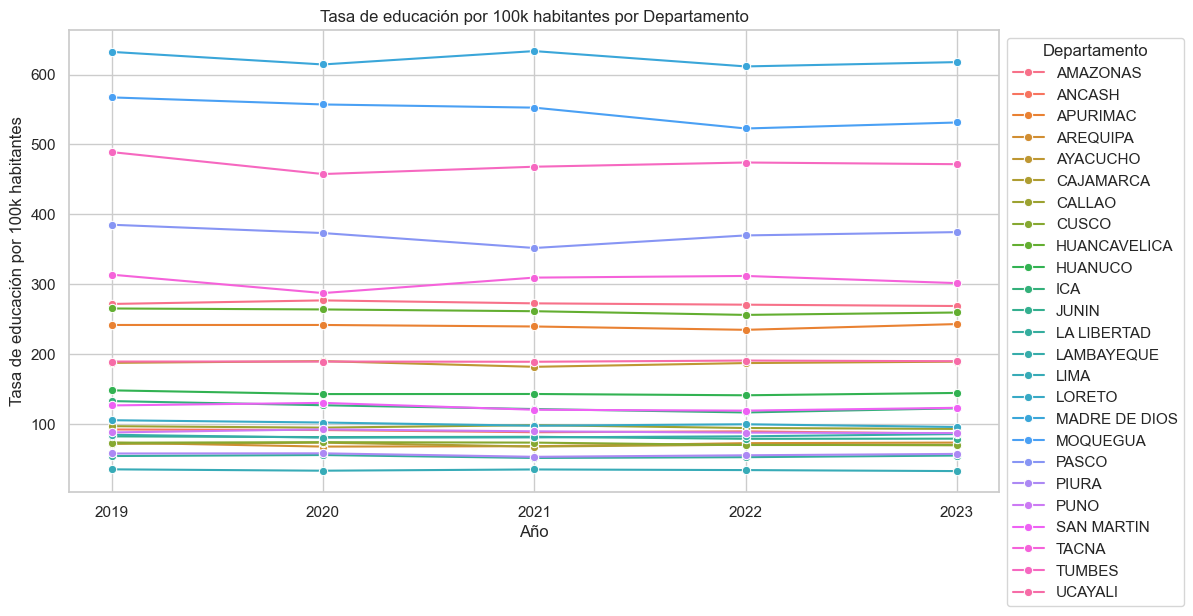

In [287]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=departamentos_mapa_ed, x='anio', y='tasa_educacion_por_100k', hue='dominio', marker='o')
plt.title("Tasa de educación por 100k habitantes por Departamento")
plt.xlabel("Año")
plt.ylabel("Tasa de educación por 100k habitantes")
plt.legend(title="Departamento", bbox_to_anchor=(1, 1), loc = 'upper left')
plt.grid(True)
plt.xticks(ticks=[2019, 2020, 2021, 2022, 2023], labels=[2019, 2020, 2021, 2022, 2023])
plt.show()

### Merge con df_hipertension_resumen

In [ ]:
df_hipertension_resumen["dominio"] = df_hipertension_resumen["dominio"].replace(mapeo_nombres)
df_hipertension_resumen["dominio"] = df_hipertension_resumen["dominio"].str.upper()

In [ ]:
porcentaje_hipertension_anio = df_hipertension_resumen.merge(departamentos[["DEPARTAMEN", "poblacion_total_2020"]].drop_duplicates(), left_on="dominio", right_on="DEPARTAMEN", how="left")
porcentaje_hipertension_anio["tasa_hipertension_por_100k"] = (porcentaje_hipertension_anio["cantidad_personas"] / porcentaje_hipertension_anio["poblacion_total_2020"]) * 100000
porcentaje_hipertension_anio.drop(columns=["DEPARTAMEN"], inplace=True)
porcentaje_hipertension_anio = porcentaje_hipertension_anio.drop_duplicates(subset=["dominio", "anio"])
display(porcentaje_hipertension_anio)

,dominio,anio,cantidad_personas,total_encuestados,porcentaje_hipertension,presion_sistolica_promedio,presion_diastolica_promedio,poblacion_total_2020,tasa_hipertension_por_100k
0,AMAZONAS,2019,410,1409,9.699551,157.510446,83.801049,472993,86.682044
1,AMAZONAS,2020,306,1427,7.147863,158.241656,84.796334,472993,64.694404
2,AMAZONAS,2021,428,1387,10.285989,157.361029,86.815328,472993,90.487597
3,AMAZONAS,2022,406,1391,9.729212,155.751342,91.923674,472993,85.836365
4,AMAZONAS,2023,349,1393,8.351280,155.956175,91.599000,472993,73.785447
...,...,...,...,...,...,...,...,...,...
120,UCAYALI,2019,222,1245,5.943775,162.360545,80.127854,632861,35.078793
121,UCAYALI,2020,201,1236,5.420712,157.561203,85.124448,632861,31.760529
122,UCAYALI,2021,255,1240,6.854839,155.437373,87.705329,632861,40.293208
123,UCAYALI,2022,266,1247,7.110398,157.020874,89.529170,632861,42.031347


In [ ]:
df_hipertension_resumen["dominio"] = df_hipertension_resumen["dominio"].str.strip()
departamentos["DEPARTAMEN"] = departamentos["DEPARTAMEN"].str.strip()

print(df_hipertension_resumen["dominio"].dtype)
print(departamentos["DEPARTAMEN"].dtype)

object
object


In [ ]:
departamentos_mapa_hiper = departamentos.merge(porcentaje_hipertension_anio, left_on=["DEPARTAMEN", "anio"], right_on=["dominio", "anio"], how="left")

#### Mapas de calor por año

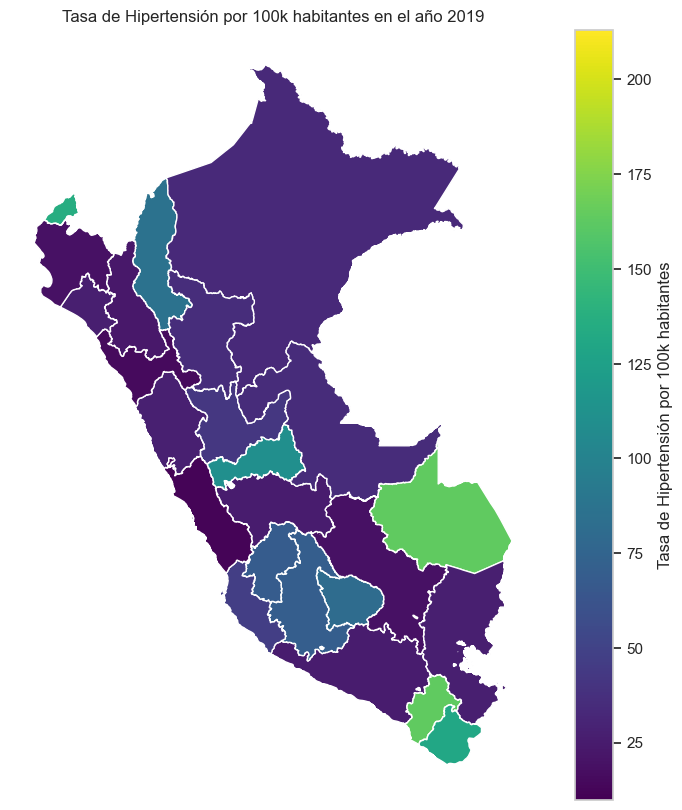

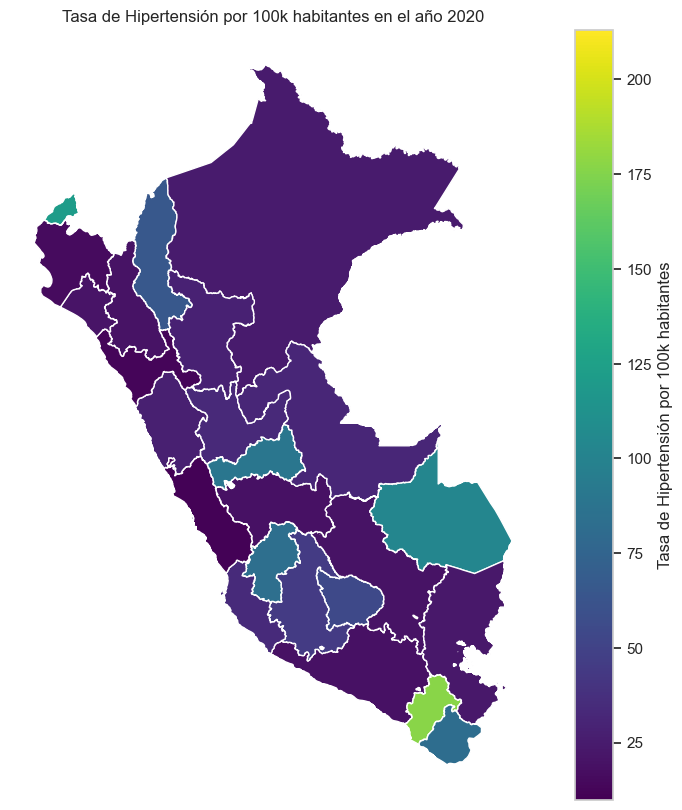

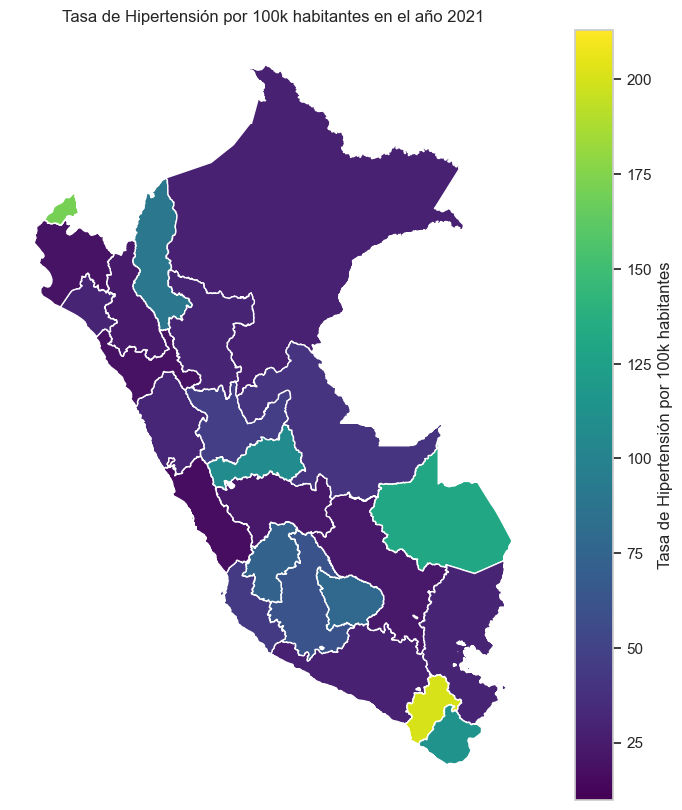

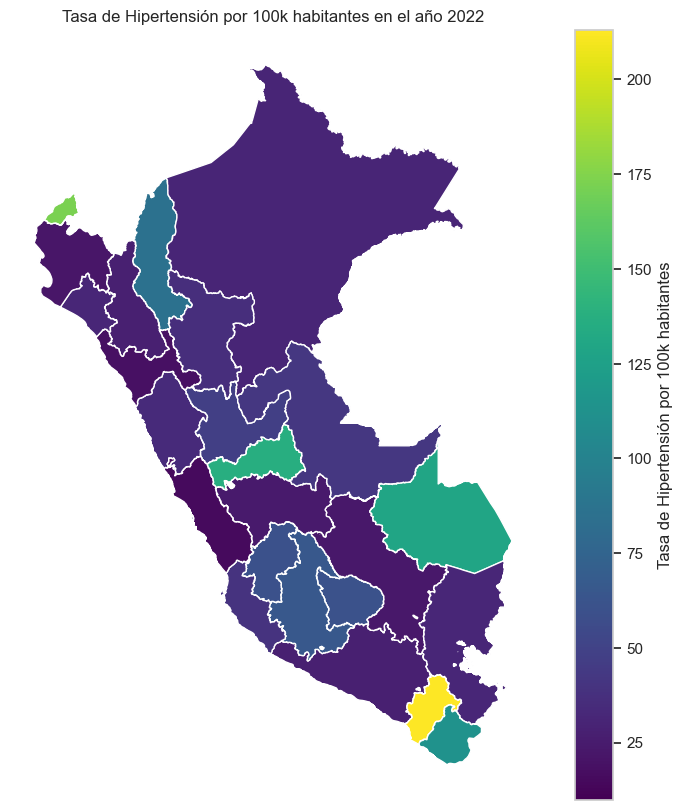

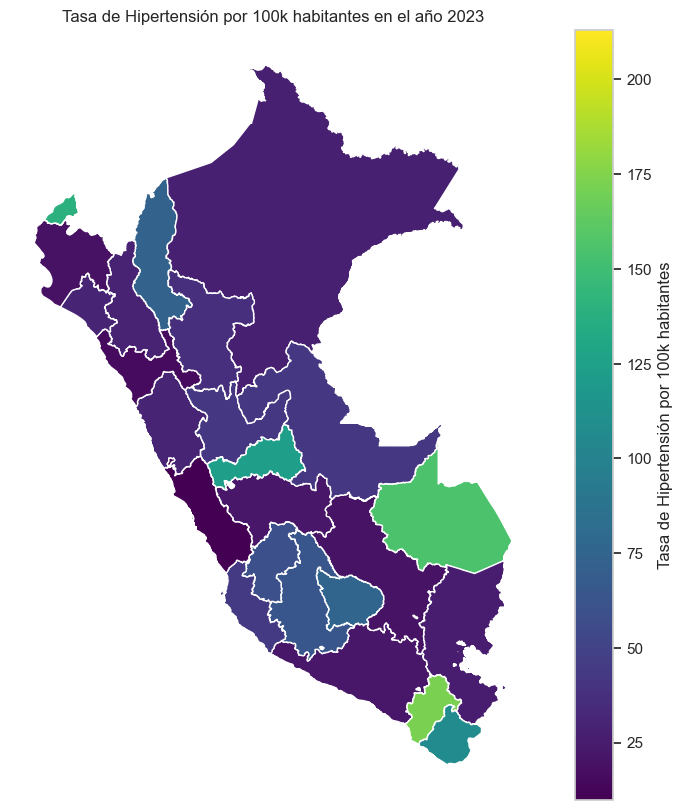

In [ ]:
vminHIP = departamentos_mapa_hiper["tasa_hipertension_por_100k"].min()
vmaxHIP = departamentos_mapa_hiper["tasa_hipertension_por_100k"].max()

for anio in departamentos_mapa_hiper["anio"].unique():
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    departamentos_mapa_anio = departamentos_mapa_hiper[departamentos_mapa_hiper["anio"] == anio]
    
    departamentos_mapa_anio.plot(
        column='tasa_hipertension_por_100k', 
        cmap='viridis',  # Prueba con viridis, plasma o cividis para mejor percepción
        ax=ax, 
        legend=True, 
        legend_kwds={'label': "Tasa de Hipertensión por 100k habitantes"},
        vmin=vminHIP, 
        vmax=vmaxHIP  # Fija la escala de colores para evitar distorsión año a año
    )

    ax.set_title(f"Tasa de Hipertensión por 100k habitantes en el año {anio}")
    ax.axis('off')
    plt.show()

#### Gráfico de líneas

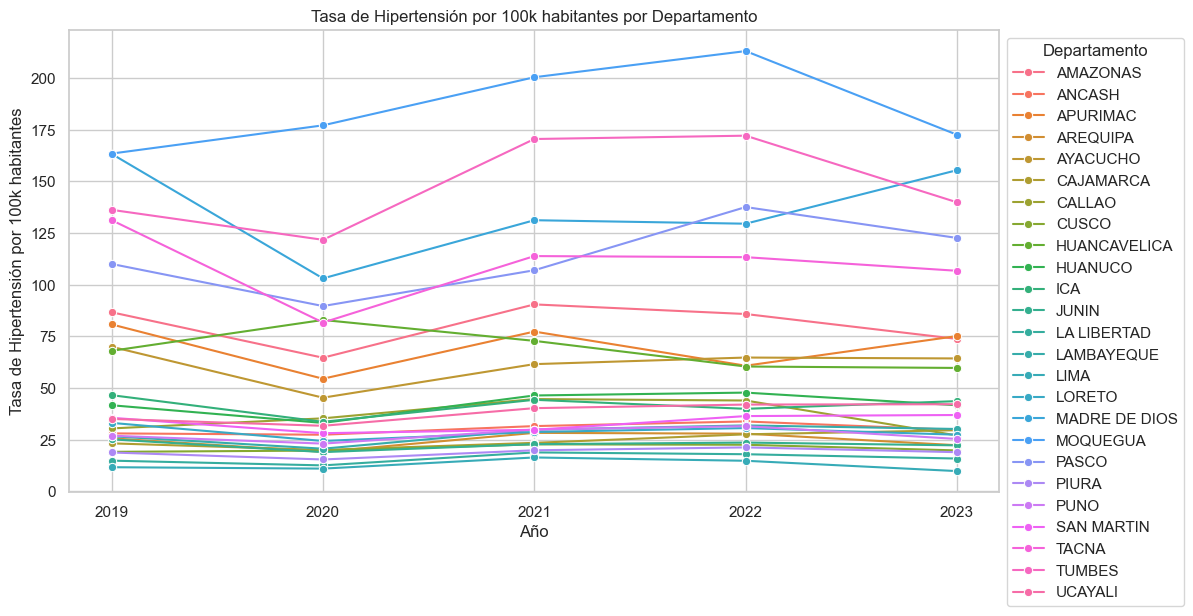

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=departamentos_mapa_hiper, x='anio', y='tasa_hipertension_por_100k', hue='dominio', marker='o')
plt.title("Tasa de Hipertensión por 100k habitantes por Departamento")
plt.xlabel("Año")
plt.ylabel("Tasa de Hipertensión por 100k habitantes")
plt.legend(title="Departamento", bbox_to_anchor=(1, 1), loc = 'upper left')
plt.grid(True)
plt.xticks(ticks=[2019, 2020, 2021, 2022, 2023], labels=[2019, 2020, 2021, 2022, 2023])
plt.show()

### Merge con df_obesidad_resumen y df_hipertension_resumen (unión)

In [ ]:
df_union_resumen["dominio"] = df_union_resumen["dominio"].replace(mapeo_nombres)
df_union_resumen["dominio"] = df_union_resumen["dominio"].str.upper()

In [ ]:
porcentaje_union_anio = df_union_resumen.merge(departamentos[["DEPARTAMEN", "poblacion_total_2020"]].drop_duplicates(), left_on="dominio", right_on="DEPARTAMEN", how="left")
porcentaje_union_anio ["tasa_union_por_100k"] = (porcentaje_union_anio["cantidad_personas"] / porcentaje_union_anio["poblacion_total_2020"]) * 100000
porcentaje_union_anio.drop(columns=["DEPARTAMEN"], inplace=True)
porcentaje_union_anio = porcentaje_union_anio.drop_duplicates(subset=["dominio", "anio"])
display(porcentaje_union_anio)

,dominio,anio,cantidad_personas,total_encuestados,imc_promedio,perimetro_abdominal_promedio,presion_sistolica_promedio,presion_diastolica_promedio,porcentaje_obesidad_hipertension,poblacion_total_2020,tasa_union_por_100k
0,AMAZONAS,2019,82,1409,36.299653,110.810908,145.106302,86.776398,0.831390,472993,17.336409
1,AMAZONAS,2020,57,1427,34.450170,108.845723,155.441248,88.562390,0.665732,472993,12.050918
2,AMAZONAS,2021,110,1387,36.241030,110.263998,145.390929,87.357560,1.132969,472993,23.256158
3,AMAZONAS,2022,88,1391,35.617623,111.187079,146.908670,92.647096,1.054397,472993,18.604926
4,AMAZONAS,2023,83,1393,36.446143,111.254356,144.692232,88.854048,0.851195,472993,17.547828
...,...,...,...,...,...,...,...,...,...,...,...
120,UCAYALI,2019,76,1245,36.818005,110.384082,147.582080,80.749969,0.872060,632861,12.008956
121,UCAYALI,2020,64,1236,37.338999,111.282568,139.781916,80.613311,0.862999,632861,10.112805
122,UCAYALI,2021,89,1240,37.168640,111.665303,153.823227,90.564874,0.797491,632861,14.063120
123,UCAYALI,2022,93,1247,37.140156,108.078224,138.328776,88.171618,1.242983,632861,14.695170


In [ ]:
df_union_resumen["dominio"] = df_union_resumen["dominio"].str.strip()
departamentos["DEPARTAMEN"] = departamentos["DEPARTAMEN"].str.strip()

print(df_union_resumen["dominio"].dtype)
print(departamentos["DEPARTAMEN"].dtype)

object
object


In [ ]:
departamentos_mapa_union = departamentos.merge(porcentaje_union_anio, left_on=["DEPARTAMEN", "anio"], right_on=["dominio", "anio"], how="left")

#### Mapas de calor por año

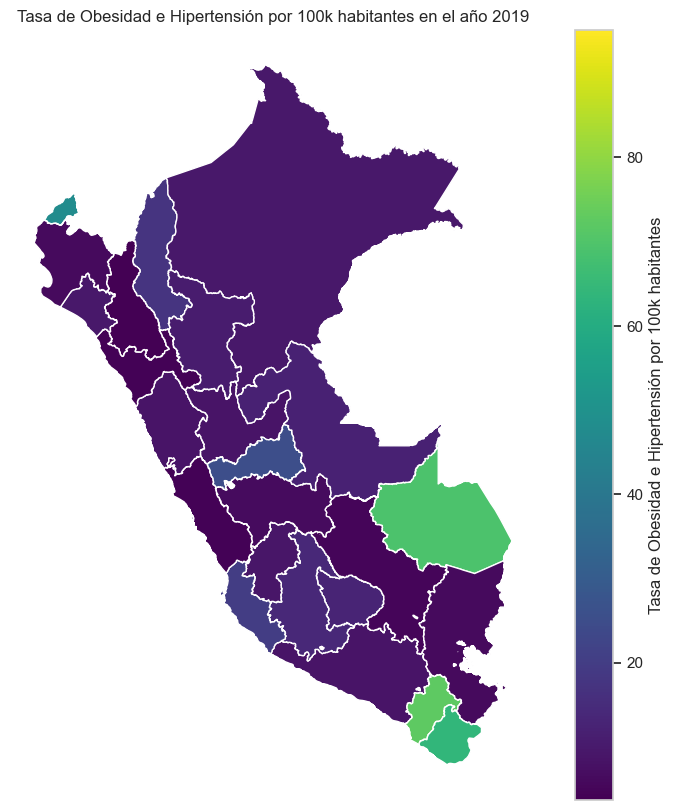

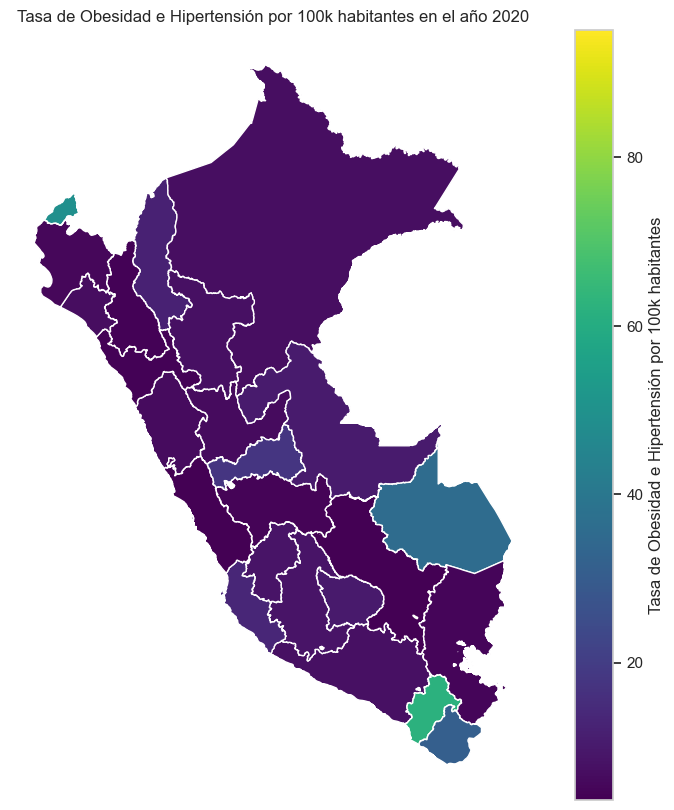

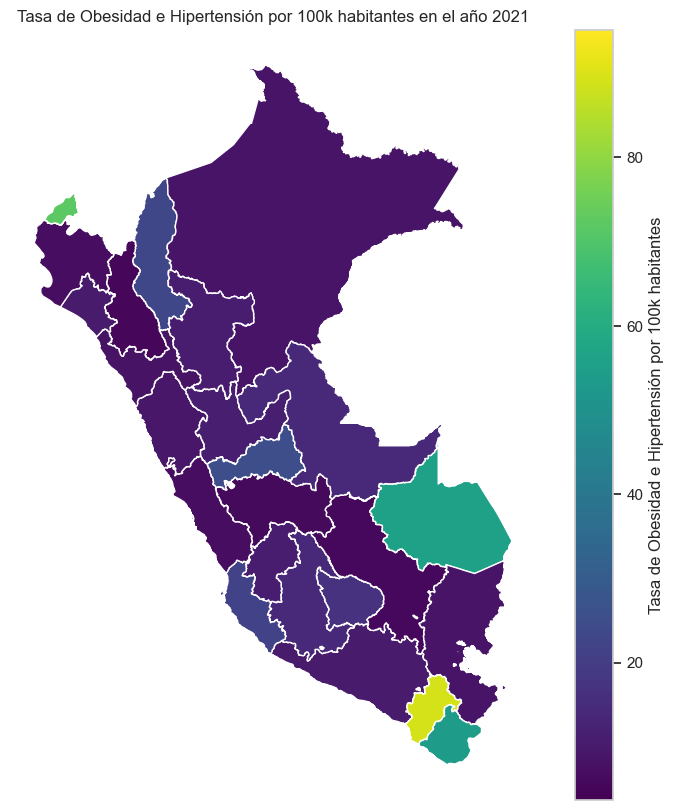

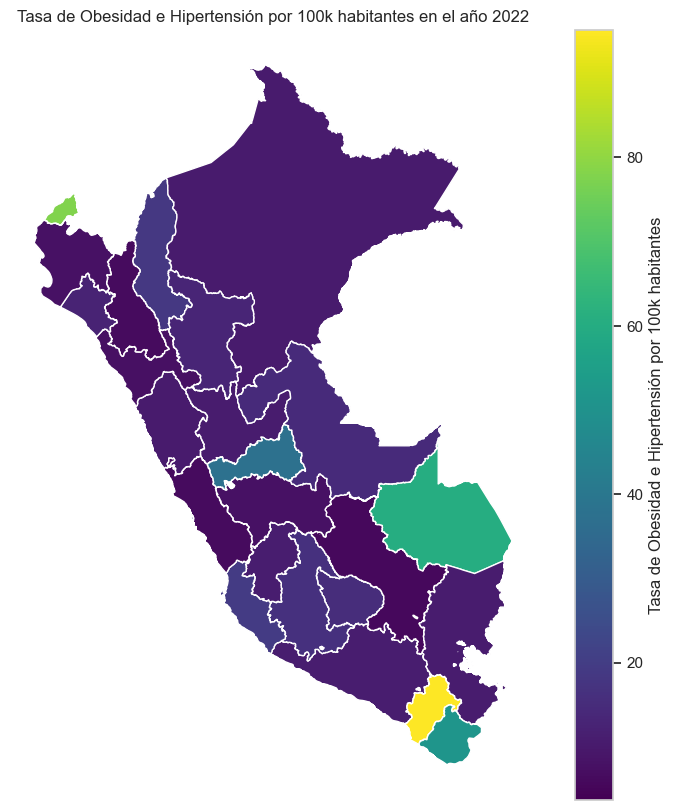

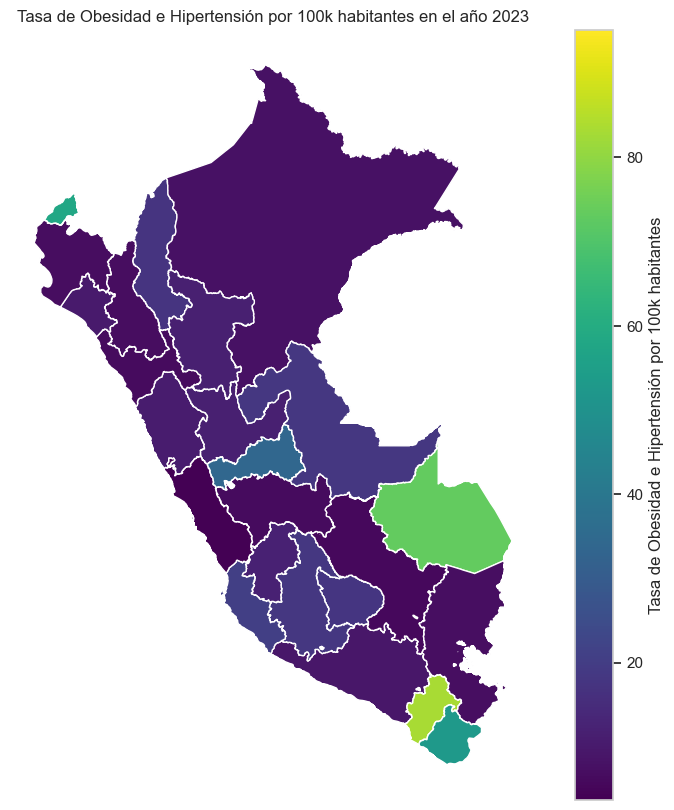

In [ ]:
vminUN = departamentos_mapa_union["tasa_union_por_100k"].min()
vmaxUN = departamentos_mapa_union["tasa_union_por_100k"].max()

for anio in departamentos_mapa_union["anio"].unique():
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    departamentos_mapa_anio = departamentos_mapa_union[departamentos_mapa_union["anio"] == anio]
    
    departamentos_mapa_anio.plot(
        column='tasa_union_por_100k', 
        cmap='viridis',  # Prueba con viridis, plasma o cividis para mejor percepción
        ax=ax, 
        legend=True, 
        legend_kwds={'label': "Tasa de Obesidad e Hipertensión por 100k habitantes"},
        vmin=vminUN, 
        vmax=vmaxUN  # Fija la escala de colores para evitar distorsión año a año
    )

    ax.set_title(f"Tasa de Obesidad e Hipertensión por 100k habitantes en el año {anio}")
    ax.axis('off')
    plt.show()

#### Gráfico de líneas

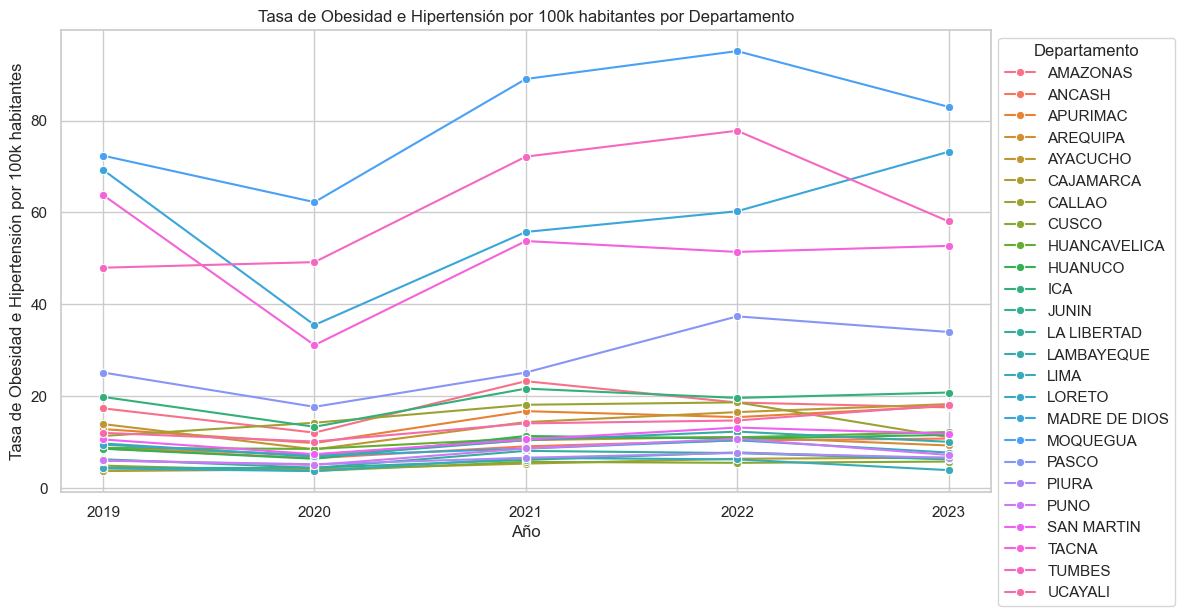

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=departamentos_mapa_union, x='anio', y='tasa_union_por_100k', hue='dominio', marker='o')
plt.title("Tasa de Obesidad e Hipertensión por 100k habitantes por Departamento")
plt.xlabel("Año")
plt.ylabel("Tasa de Obesidad e Hipertensión por 100k habitantes")
plt.legend(title="Departamento", bbox_to_anchor=(1, 1), loc = 'upper left')
plt.grid(True)
plt.xticks(ticks=[2019, 2020, 2021, 2022, 2023], labels=[2019, 2020, 2021, 2022, 2023])
plt.show()

In [ ]:
# porcentaje_obesidad_anio.to_csv("porcentaje_obesidad.csv", index=False)
# porcentaje_hipertension_anio.to_csv("porcentaje_hipertension.csv", index=False)
# porcentaje_union_anio.to_csv("porcentaje_union.csv", index=False)
#porcentaje_educacion_anio.to_csv("porcentaje_educacion.csv", index=False)

In [ ]:
# salud.to_excel("salud.xlsx", index=False)

#### Plots antiguos

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# print(salud.institucion_seguro.value_counts())

In [ ]:
# plt.figure(figsize=(12, 8))
# sns.scatterplot(data=salud[(salud.longitud < -60) & (salud.latitud > -30)],
#                 x='longitud',
#                 y='latitud',
#                 hue='diagnostico_hipertension',
#                 palette="coolwarm", alpha=0.6)

# plt.title("Distribución de la Hipertensión por Ubicación")
# plt.xlabel("Longitud")
# plt.ylabel("Latitud")
# plt.legend(title="Hipertensión")
# plt.show()


In [ ]:
# sns.boxplot(data=presion_agrupada, y='region', x='presion_sis_1', orient="h")
# plt.title("Presión Sistólica por Región")
# plt.xlabel("Región")
# plt.ylabel("Presión Sistólica")
# plt.show()

In [ ]:
# presion_agrupada = salud.groupby(["region", "anio"]).agg({"presion_sis_1": "mean", "id_hogar": "count"}).reset_index()
# display(presion_agrupada)
# presion_agrupada.columns = ["region", "anio", "presion_sis_1", "conteo"]
# # PROMEDIAR AMBAS MEDICIONES DE SISTOLE

# plt.figure(figsize=(12, 6))
# sns.lineplot(data=presion_agrupada, x='anio', y='presion_sis_1', hue='region')
# plt.title("Presión Sistólica Promedio por Año y Región")
# plt.xticks(presion_agrupada.anio.unique())
# plt.xlabel("Año")
# plt.ylabel("Presión Sistólica Promedio")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.show()

In [ ]:
# porc_seguro_por_region = salud.groupby(["region", "anio", "seguro_salud"]).agg({"id_hogar": "count"}).reset_index()
# display(porc_seguro_por_region)
# porc_seguro_por_region.columns = ["region", "anio", "seguro_salud", "conteo"]
# porc_seguro_por_region = porc_seguro_por_region.pivot_table(index=["region", "anio"], columns="seguro_salud", values="conteo").reset_index()
# display(porc_seguro_por_region)
# porc_seguro_por_region["total"] = porc_seguro_por_region["si"] + porc_seguro_por_region["no"]
# porc_seguro_por_region["porcentaje_seguro"] = porc_seguro_por_region["si"] / porc_seguro_por_region["total"] * 100
# display(porc_seguro_por_region)

In [ ]:
# plt.figure(figsize=(12, 6))
# sns.lineplot(data=porc_seguro_por_region, x='anio', y='porcentaje_seguro', hue='region')
# plt.title("Porcentaje de Personas con Seguro de Salud por Año y Región")
# plt.xticks(porc_seguro_por_region.anio.unique())
# plt.xlabel("Año")
# plt.ylabel("Porcentaje de Personas con Seguro de Salud")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.show()

In [ ]:
# porc_hipertension_por_region = salud.groupby(["region", "anio", "diagnostico_hipertension"]).agg({"id_hogar": "count"}).reset_index()
# porc_hipertension_por_region.columns = ["region", "anio", "diagnostico_hipertension", "conteo"]
# porc_hipertension_por_region = porc_hipertension_por_region.pivot_table(index=["region", "anio"], columns="diagnostico_hipertension", values="conteo").reset_index()
# porc_hipertension_por_region["total"] = porc_hipertension_por_region["si"] + porc_hipertension_por_region["no"]
# porc_hipertension_por_region["porcentaje_hipertension"] = porc_hipertension_por_region["si"] / porc_hipertension_por_region["total"] * 100

In [ ]:
# plt.figure(figsize=(12, 6))
# sns.lineplot(data=porc_hipertension_por_region, x='anio', y='porcentaje_hipertension', hue='region')
# plt.title("Porcentaje de Personas con Hipertensión por Año y Región")
# plt.xticks(porc_hipertension_por_region.anio.unique())
# plt.xlabel("Año")
# plt.ylabel("Porcentaje de Personas con Hipertensión")
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.show()

In [ ]:
display(salud)

#### LIMPIEZA E IMPUTACIÓN DE ROWS

In [ ]:
display(salud)

* num_persona

In [ ]:
#convierte los valores de la columna num_persona " " a nan
salud["num_persona"] = pd.to_numeric(salud["num_persona"], errors="coerce")

print(salud["num_persona"].isna().sum())

In [ ]:
#imputa los valores nan de la columna num_persona de salud con el valor 0
salud["num_persona"].fillna(0, inplace=True)

#convierte la columna num_persona a objeto
salud["num_persona"] = salud["num_persona"].astype(str)

Estoy creando un id_encuesta porque hay 35 645 row con el mismo id_hogar, pero son diferentes encuestas, en diferentes años y posiblemente diferentes personas. 

In [ ]:
#muestrame los row de salud donde la columna id_hogar se repite
(salud[salud.duplicated(subset=["id_hogar"], keep=False)])

In [ ]:
#crea una columna id_encuesta en salud por cada row y llena de 1 a n
salud["id_encuesta"] = range(1, len(salud) + 1)

* edad

In [ ]:
salud["edad"] = pd.to_numeric(salud["edad"], errors="coerce")
print(salud["edad"].isna().sum())

In [ ]:
#MEDIANA POR DOMINIO
mediana_edad = salud.groupby("dominio")["edad"].median()

#IMPUTACIÓN
salud.loc[salud["edad"].isna(), "edad"] = (
    salud.loc[salud["edad"].isna(), "dominio"].map(mediana_edad)
    + np.random.randint(-3, 4, size=salud["edad"].isna().sum()) # del 2019 al 2023
).round(0)

Las variables sexo y diagnóstico_hipertension se imputa utilizando choice(["a", "b"]) porque son categóricas binaria, donde solo existen dos posibles respuestas. 

* sexo

In [ ]:
print(salud["sexo"].isna().sum())

# #convierte los nan en "Desconocido"
# salud["sexo"].fillna("Desconocido", inplace=True)

print(salud["sexo"].value_counts())

In [ ]:
from scipy.stats import chi2_contingency

for col in ["dominio", "area_residencia", "lugar_residencia"]:
    tabla = pd.crosstab(salud[col], salud["sexo"])
    chi2, p, dof, ex = chi2_contingency(tabla)
    print(f"{col} - p-valor: {p:.4f}")

In [ ]:
#IMPUTACIÓN DE SEXO
probs_sexo = salud.groupby("dominio")["sexo"].value_counts(normalize=True).unstack()

def imputar_sexo(row):
    if pd.isna(row["sexo"]):
        return np.random.choice(["hombre", "mujer"], p=[probs_sexo.loc[row["dominio"], "hombre"], probs_sexo.loc[row["dominio"], "mujer"]])
    return row["sexo"]

salud["sexo"] = salud.apply(imputar_sexo, axis=1)

print(salud["sexo"].value_counts())
len(salud["sexo"])

* diagnostico_hipertension

In [ ]:
print(salud["diagnostico_hipertension"].value_counts())
print(salud["diagnostico_hipertension"].isna().sum())

In [ ]:
#convertir los valores no_sabe_no_recuerda a nan
salud["diagnostico_hipertension"] = salud["diagnostico_hipertension"].replace("no_sabe_no_recuerda", np.nan)
print(salud["diagnostico_hipertension"].isna().sum())

In [ ]:
#IMPUTACIÓN DE HIPERTENSIÓN
probs_hipertension = salud.groupby("dominio")["diagnostico_hipertension"].value_counts(normalize=True).unstack()

def imputar_hipertension(row):
    if pd.isna(row["diagnostico_hipertension"]):
        return np.random.choice(["si", "no"], p=[probs_hipertension.loc[row["dominio"], "si"], probs_hipertension.loc[row["dominio"], "no"]])
    return row["diagnostico_hipertension"]

salud["diagnostico_hipertension"] = salud.apply(imputar_hipertension, axis=1)

print(salud["diagnostico_hipertension"].value_counts())

* peso_kg, talla_cm, perimetro_abdominal_cm

In [ ]:
print(salud["peso_kg"].isna().sum())
print(salud["talla_cm"].isna().sum())
print(salud["perimetro_abdominal_cm"].isna().sum())

In [ ]:
# limpieza de los que tienen 999.9
salud["peso_kg"] = salud["peso_kg"].replace(999.9, np.nan)
salud["talla_cm"] = salud["talla_cm"].replace(999.9, np.nan)
salud["perimetro_abdominal_cm"] = salud["perimetro_abdominal_cm"].replace(999.9, np.nan)

In [ ]:
#MEDIANA POR DOMINIO
peso_media = salud.groupby("dominio").peso_kg.mean()
talla_media = salud.groupby("dominio").talla_cm.mean()
perimetro_media = salud.groupby("dominio").perimetro_abdominal_cm.mean()

# IMPUTACIÓN
salud.loc[salud["peso_kg"].isna(), "peso_kg"] = (
    salud.loc[salud["peso_kg"].isna(), "dominio"].map(peso_media)  
    + np.random.normal(0, 2, size=salud["peso_kg"].isna().sum())  
).round(1)

salud.loc[salud["talla_cm"].isna(), "talla_cm"] = (
    salud.loc[salud["talla_cm"].isna(), "dominio"].map(talla_media) 
    + np.random.normal(0, 1, size=salud["talla_cm"].isna().sum())
).round(1)

salud.loc[salud["perimetro_abdominal_cm"].isna(), "perimetro_abdominal_cm"] = (
    salud.loc[salud["perimetro_abdominal_cm"].isna(), "dominio"].map(perimetro_media)  
    + np.random.normal(0, 3, size=salud["perimetro_abdominal_cm"].isna().sum()) 
).round(1)


In [ ]:
print(salud["peso_kg"].isna().sum())
print(salud["talla_cm"].isna().sum())
print(salud["perimetro_abdominal_cm"].isna().sum())

* presion_sis_1, presion_sis_2, presion_dia_1, presion_dia_2

In [ ]:
salud["presion_sis_1"] = pd.to_numeric(salud["presion_sis_1"], errors="coerce")
salud["presion_sis_2"] = pd.to_numeric(salud["presion_sis_2"], errors="coerce")
salud["presion_dia_1"] = pd.to_numeric(salud["presion_dia_1"], errors="coerce")
salud["presion_dia_2"] = pd.to_numeric(salud["presion_dia_2"], errors="coerce")

In [ ]:
#limpieza de los que tienen 999.0 a nan
salud["presion_sis_1"] = salud["presion_sis_1"].replace(999.0, np.nan)
salud["presion_sis_2"] = salud["presion_sis_2"].replace(999.0, np.nan)
salud["presion_dia_1"] = salud["presion_dia_1"].replace(999.0, np.nan)
salud["presion_dia_2"] = salud["presion_dia_2"].replace(999.0, np.nan)

print(salud["presion_sis_1"].isna().sum())
print(salud["presion_sis_2"].isna().sum())
print(salud["presion_dia_1"].isna().sum())
print(salud["presion_dia_2"].isna().sum())

In [ ]:
#MEDIANA POR DOMINIO
presion_sis_1_media = salud.groupby("dominio").presion_sis_1.mean()
presion_sis_2_media = salud.groupby("dominio").presion_sis_2.mean()
presion_dia_1_media = salud.groupby("dominio").presion_dia_1.mean()
presion_dia_2_media = salud.groupby("dominio").presion_dia_2.mean()

# IMPUTACIÓN
salud.loc[salud["presion_sis_1"].isna(), "presion_sis_1"] = (
    salud.loc[salud["presion_sis_1"].isna(), "dominio"].map(presion_sis_1_media)  
    + np.random.normal(0, 5, size=salud["presion_sis_1"].isna().sum())  
).round(0)

salud.loc[salud["presion_sis_2"].isna(), "presion_sis_2"] = (
    salud.loc[salud["presion_sis_2"].isna(), "dominio"].map(presion_sis_2_media)  
    + np.random.normal(0, 4, size=salud["presion_sis_2"].isna().sum())  
).round(0)

salud.loc[salud["presion_dia_1"].isna(), "presion_dia_1"] = (
    salud.loc[salud["presion_dia_1"].isna(), "dominio"].map(presion_dia_1_media)  
    + np.random.normal(0, 3, size=salud["presion_dia_1"].isna().sum())  
).round(0)

salud.loc[salud["presion_dia_2"].isna(), "presion_dia_2"] = (
    salud.loc[salud["presion_dia_2"].isna(), "dominio"].map(presion_dia_2_media)  
    + np.random.normal(0, 2, size=salud["presion_dia_2"].isna().sum())  
).round(0)

print(salud["presion_sis_1"].isna().sum())
print(salud["presion_sis_2"].isna().sum())
print(salud["presion_dia_1"].isna().sum())
print(salud["presion_dia_2"].isna().sum())

#### MODELO RANDOM FOREST PARA IMPUTACIÓN DE EDAD Y SEXO

In [ ]:
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [ ]:
# # SET DE ENTRENAMIENTO
# XY = salud[["sexo", "dominio", "area_residencia", "lugar_residencia", "anio"]].dropna().to_numpy()
# print(XY)

In [ ]:
# # x train y train
# x_train = XY[:,1:5]
# y_train = XY[:,0]
# print(x_train)

In [ ]:
# print(y_train)

In [ ]:
# # SET DE PRUEBA
# filas = salud[~salud['sexo'].notna()].index

# x_test = salud[["dominio", "area_residencia", "lugar_residencia", "anio"]].iloc[filas].to_numpy()
# print(x_test)

In [ ]:
# print(x_train)

In [ ]:
# he = OneHotEncoder()
# le = LabelEncoder()

# he.fit(x_train[:,0:3])
# x_train_encoded = he.transform(x_train[:,0:3]).toarray()
# x_train = np.hstack([x_train_encoded, x_train[:,3].reshape(-1,1)])

# le.fit(y_train)
# y_train = le.transform(y_train)

# he.fit(x_test[:,0:3])
# x_test_encoded = he.transform(x_test[:,0:3]).toarray()
# x_test = np.hstack([x_test_encoded, x_test[:,3].reshape(-1,1)])

In [ ]:
# from imblearn.over_sampling import SMOTE
# from collections import Counter

# # Aplicar SMOTE al conjunto de entrenamiento
# smote = SMOTE(sampling_strategy='auto', random_state=42)
# x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)

# print("Distribución después de SMOTE:", Counter(y_train_bal))

In [ ]:
# # Entrenar el modelo con los datos balanceados
# rf = RandomForestClassifier(n_estimators=300, random_state=42)
# rf.fit(x_train_bal, y_train_bal)
# preds = rf.predict(x_test)
# print(preds)


In [ ]:
# acc=accuracy_score(y_train, rf.predict(x_train))
# print(acc)

In [ ]:
# feature_importance = rf.feature_importances_

# # Crear DataFrame con índices numéricos
# features = pd.DataFrame({'Feature': np.arange(len(feature_importance)), 'Importance': feature_importance})

# # Ordenar y mostrar
# features = features.sort_values(by='Importance', ascending=False)
# print(features.head(10))

In [ ]:
# # from scipy.stats import ks_2samp

# # for col in features:
# #     stat, p_value = ks_2samp(salud[col].dropna(), salud_imputed[col])
# #     print(f"{col}: p-value = {p_value:.4f}")


#### MODELO RANOOM FOREST REGRESSOR PARA IMPUTACIÓN DE PESO, TALLA, PERÍMETRO ABDOMINAL Y PRESIONES

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
features = ["edad", "peso_kg", "talla_cm", "perimetro_abdominal_cm", 
            "presion_sis_1", "presion_sis_2", "presion_dia_1", "presion_dia_2"]

In [ ]:
#ONE HOT ENCODING
he = OneHotEncoder()

categorical_cols = ["area_residencia", "lugar_residencia", "dominio", "sexo"]

categoricals_col_encoded = he.fit[:,0,4].toarray()



salud_encoded = pd.get_dummies(salud, columns=categorical_cols, drop_first=True)

In [ ]:
selected_columns = features + ["anio"] + list(salud_encoded.columns.difference(salud.columns))

X = salud_encoded[selected_columns]

In [ ]:
#ESTANDARIZACIÓN DE DATOS
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[features] = scaler.fit_transform(X[features])

In [ ]:
# # GRUPOS CORRELACIONADOS
# grupo_presion = ["presion_sis_1", "presion_sis_2", "presion_dia_1", "presion_dia_2"]
# grupo_antropometrico = ["edad", "peso_kg", "talla_cm", "perimetro_abdominal_cm"]

In [ ]:
display(salud)

In [ ]:
# Aplicar KNN Imputation with k=5 (can be adjusted based on validation)
from sklearn.impute import KNNImputer


imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_scaled)

# Convert back to DataFrame
salud_imputed = pd.DataFrame(X_imputed, columns=X.columns)

# Undo the standardization
salud_imputed[features] = scaler.inverse_transform(salud_imputed[features])

# Replace imputed values in the original dataset
salud[features] = salud_imputed[features]

In [ ]:
# salud.loc[:, grupo_presion] = X[grupo_presion]
# salud.loc[:, grupo_antropometrico] = X[grupo_antropometrico]

In [ ]:
# #exporta el archivo salud
# salud.to_excel("salud.xlsx", index=False)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in features:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(salud[col].dropna(), label="Antes", color="blue")
    sns.kdeplot(X[col], label="Después", color="red")
    plt.title(f"Distribución de {col} antes y después de la imputación")
    plt.legend()
    plt.show()


In [ ]:
print(salud["edad"].isna().sum())
print(salud["peso_kg"].isna().sum())
print(salud["talla_cm"].isna().sum())
print(salud["perimetro_abdominal_cm"].isna().sum())
print(salud["presion_sis_1"].isna().sum())
print(salud["presion_sis_2"].isna().sum())
print(salud["presion_dia_1"].isna().sum())
print(salud["presion_dia_2"].isna().sum())

#### EXCLUSIÓN DE MENORES DE 18 AÑOS

In [ ]:
#eliminar de salud los rows con edad menor a 18
salud = salud[salud["edad"] >= 18]
display(salud)

#### IMC: NCBI

In [ ]:
salud["imc"] = salud["peso_kg"] / (salud["talla_cm"] / 100) ** 2

In [ ]:
#ESTÁNDARES SEGÚN NCBI
def categorizar_imc(imc):
    if imc < 18.5:
        return "Bajo peso"
    elif imc >= 18.5 and imc <= 24.9:
        return "Peso normal"
    elif imc >= 25.0 and imc <= 29.9:
        return "Sobrepeso"
    elif imc >= 30.0 and imc <= 34.9:
        return "Obesidad Clase I"
    elif imc >= 35.0 and imc <= 39.9:
        return "Obesidad Clase II"
    elif imc >= 40.0:
        return "Obesidad Clase III"
    else:
        return "Valor fuera de rango"  # Para manejar posibles errores


In [ ]:
#imprime el número de valores que tiene cada categoría de imc
salud["categoria_imc"] = salud["imc"].apply(categorizar_imc)
salud["categoria_imc"].value_counts()

In [ ]:
#imprime el máximo y mímimo imc por categoría_imc
salud.groupby("categoria_imc")["imc"].agg(["min", "max"])

In [ ]:
print(salud["imc"].describe())
display(salud)

#### Limpieza anterior

In [ ]:
# #imprime el número de valores únicos en imc con categoria peso muy inferior al normal
# print(salud[salud["categoria_imc"] == "Peso muy inferior al normal"]["imc"].nunique())

In [ ]:
# # Calcular la mediana corregida para "Peso muy inferior al normal"
# filtro_valido = (salud["categoria_imc"] == "Peso muy inferior al normal") & (salud["imc"].round(6) > 10.001000)
# if filtro_valido.any():
#     mediana_corregida = salud.loc[filtro_valido, "imc"].median()
#     print(f"Mediana corregida para 'Peso muy inferior al normal': {mediana_corregida}")

# medianas_imc = salud.loc[(salud["imc"] > 10.001) & (salud["imc"] <= 100)].groupby("categoria_imc")["imc"].median()

# if "Peso muy inferior al normal" in medianas_imc.index:
#     print(f"Reemplazando mediana original {medianas_imc['Peso muy inferior al normal']} con {mediana_corregida}")
#     medianas_imc.loc["Peso muy inferior al normal"] = mediana_corregida

# def imputar_imc(row):
#     if row["categoria_imc"] == "Peso muy inferior al normal" and row["imc"] <= 10.05:
#         return mediana_corregida
#     elif row["imc"] > 100 or row["imc"] < 10.001:
#         return medianas_imc.get(row["categoria_imc"], row["imc"])
#     return row["imc"]

In [ ]:
# salud["imc"] = salud.apply(imputar_imc, axis=1)
# salud["categoria_imc"] = salud["imc"].apply(categorizar_imc)

In [ ]:
# print(medianas_imc)

In [ ]:
# # Excluir valores incorrectos antes de calcular la mediana
# medianas_perimetro = salud[salud["perimetro_abdominal_cm"] != 999.9].groupby("categoria_imc")["perimetro_abdominal_cm"].median()
# print(medianas_perimetro)  # Verificar las medianas calculadas


In [ ]:
# # Imputar los valores erróneos de 999.9 con la mediana de su categoría de IMC
# def imputar_perimetro(row):
#     if row["perimetro_abdominal_cm"] == 999.9:
#         return medianas_perimetro[row["categoria_imc"]]
#     return row["perimetro_abdominal_cm"]

# salud["perimetro_abdominal_cm"] = salud.apply(imputar_perimetro, axis=1)

In [ ]:
# categoria_imc_agrupada = salud.groupby("categoria_imc").size().reset_index(name="count")

In [ ]:
# # Imputar los valores NaN con la mediana correspondiente de su categoría
# for categoria, mediana in medianas_perimetro.items():
#     salud.loc[(salud["categoria_imc"] == categoria) & (salud["perimetro_abdominal_cm"].isna()), "perimetro_abdominal_cm"] = mediana

# # Verificar que ya no haya NaN en la columna
# print(salud["perimetro_abdominal_cm"].isna().sum())  # Debería imprimir 0 si todo está bien

In [ ]:
# print(salud["imc"].isna().sum())
# print(salud["id_hogar"].isna().sum())

#### Gráfico de dispersión: IMC vs Perímetro abdominal

In [ ]:
df_agrupado = salud[["imc", "perimetro_abdominal_cm", "categoria_imc", "id_encuesta"]].copy()

In [ ]:
len(df_agrupado)

In [ ]:
orden_categorias = {
    "Peso muy inferior al normal": 1,
    "Bajo peso": 2,
    "Peso normal": 3,
    "Sobrepeso": 4,
    "Obesidad Clase I": 5,
    "Obesidad Clase II": 6,
    "Obesidad Clase III": 7
}

In [ ]:
df_agrupado["orden"] = df_agrupado["categoria_imc"].map(orden_categorias)
df_agrupado = df_agrupado.sort_values("orden")

In [ ]:
salud.groupby("categoria_imc")["perimetro_abdominal_cm"].describe()


In [ ]:
plt.figure(figsize=(12, 6))

#scatter plot con categoria imc agrupada
sns.scatterplot(data=df_agrupado, x="imc", y="perimetro_abdominal_cm", hue="categoria_imc", palette="coolwarm", alpha=0.5)

#lineas verticales de referencia para las categorías de IMC
for x in [16.5, 18.5, 25, 30, 35, 40]:
    plt.axvline(x, color='gray', linestyle='--', alpha=0.6)
    
plt.title("IMC vs Perímetro Abdominal")
plt.xlabel("IMC")
plt.ylabel("Perímetro Abdominal")
plt.legend(title="Categoría IMC", bbox_to_anchor=(1, 1))
plt.show()

In [ ]:
# plt.figure(figsize=(12, 6))
# salud_nomissing = salud.dropna(subset=["imc"])
# sns.boxplot(data=salud_nomissing[salud_nomissing["imc"]<300], x="anio", y="imc")
# # sns.violinplot(data=salud_nomissing[salud_nomissing["imc"]<300], x="anio", y="imc", hue="sexo", split=True)

# plt.title("Distribución del IMC por Año")
# plt.xlabel("Año")
# plt.ylabel("IMC")
# plt.show()

In [ ]:
# # perimetro abdominal y sexo
# plt.figure(figsize=(12, 6))
# salud_nomissing = salud.dropna(subset=["perimetro_abdominal_cm"])
# sns.boxplot(data=salud_nomissing[salud_nomissing["perimetro_abdominal_cm"]< 800], x="anio", y="perimetro_abdominal_cm")

# plt.title("Distribución del Perímetro Abdominal por Año")
# plt.xlabel("Año")
# plt.ylabel("Perímetro Abdominal")
# plt.show()

#### HIPERTENSIÓN

In [ ]:
# Calcular el promedio de la presión sistólica y diastólica
salud["presion_sis_promedio"] = salud[["presion_sis_1", "presion_sis_2"]].mean(axis=1)
salud["presion_dia_promedio"] = salud[["presion_dia_1", "presion_dia_2"]].mean(axis=1)

In [ ]:
len(salud["presion_dia_promedio"])

In [ ]:
# Definir función para categorizar la presión arterial
def categorizar_presion(sistolica, diastolica):
    if sistolica >= 180 or diastolica > 120:
        return "Crisis Hipertensiva (Hipertensión Etapa 3)"
    elif sistolica >= 140 or diastolica >= 90:
        return "Hipertensión Etapa 2"
    elif sistolica >= 130 or diastolica >= 80:
        return "Hipertensión Etapa 1"
    elif sistolica >= 120 and diastolica < 80:
        return "Elevado"
    else:
        return "Normal"

# Aplicar la categorización
salud["categoria_presion"] = salud.apply(
    lambda row: categorizar_presion(row["presion_sis_promedio"], row["presion_dia_promedio"]), axis=1
)


In [ ]:
print(salud["presion_sis_promedio"].describe())
print(salud["presion_dia_promedio"].describe())
print(salud["categoria_presion"].value_counts())

In [ ]:
#agrgar diagnostico_hipertension y categoria_presion a df_agrupado
df_agrupado["diagnostico_hipertension"] = salud["diagnostico_hipertension"].values

df_agrupado["categoria_presion"] = salud["categoria_presion"].values
display(df_agrupado)

#### Histograma de promedio de presiones

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.histplot(salud["presion_sis_promedio"], bins=20, kde=True, color="blue", label="Sistólica")
sns.histplot(salud["presion_dia_promedio"], bins=20, kde=True, color="red", label="Diastólica")
plt.title("Distribución de la Presión Arterial Promedio")
plt.xlabel("Presión Arterial")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

#### Histograma de diagnostico_hipertension

In [ ]:
print(salud["diagnostico_hipertension"].unique())  

In [ ]:
# Gráfico de barras: Frecuencia de hipertensión (Sí/No)
plt.figure(figsize=(12, 6))
sns.countplot(data=salud, x="diagnostico_hipertension", palette="viridis")
plt.title("Frecuencia de Hipertensión")
plt.xlabel("Diagnóstico de Hipertensión")
plt.ylabel("Cantidad de Personas")
plt.yscale("log")
plt.show()

In [ ]:
print(salud.columns)

#### fuma_diario (no ingresa)

In [ ]:
salud["fuma_diario"] = salud["fuma_diario"].fillna("Desconocido")
print(salud["fuma_diario"].unique())

In [ ]:
print(salud["fuma_diario"].value_counts(normalize=True))

#### fumo_30d (no ingresa)

In [ ]:
salud["fumo_30d"] = salud["fumo_30d"].fillna("Desconocido")
print(salud["fumo_30d"].unique())

In [ ]:
print(salud["fumo_30d"].value_counts())

#### alcohol_30d (no ingresa)

In [ ]:
salud["alcohol_30d"] = salud["alcohol_30d"].fillna("Desconocido")
print(salud["alcohol_30d"].unique())

In [ ]:
print(salud["alcohol_30d"].value_counts(normalize=True))

In [ ]:
# número de valores faltants por columna en salud
print(salud.isna().sum())


In [ ]:
# descargar el archivo salud
salud.to_csv("salud.csv", index=False)

## Instrucción

### asistio_escuela

In [ ]:
salud['asistio_escuela'] = salud['asistio_escuela'].fillna("Desconocido")
print(salud['asistio_escuela'].unique())

In [ ]:
print(salud['asistio_escuela'].value_counts(normalize=True))

### nivel_aprobado

In [ ]:
salud["nivel_aprobado"] = salud["nivel_aprobado"].fillna("Desconocido")
print(salud["nivel_aprobado"].unique())

In [ ]:
print(salud["nivel_aprobado"].value_counts(normalize=True))

In [ ]:
#calcular el promedio de los valores de nivel_aprobado

## VARIABLES

### Data educación

In [ ]:
# categoria_nivel_dominio = salud.groupby(['dominio', 'anio', 'nivel_aprobado']).agg(
#     cantidad_personas=('id_hogar', 'count'),
# ).reset_index()

total_personas = salud.groupby(["dominio", "anio"]).agg(
    total_encuestados=("id_hogar", "count")
).reset_index()

In [ ]:
# display(categoria_nivel_dominio)

In [ ]:
# df_final_nivel = categoria_nivel_dominio.merge(total_personas, on=["dominio", "anio"], how="left")
# df_final_nivel["porcentaje_nivel"] = df_final_nivel["cantidad_personas"] / df_final_nivel["total_encuestados"] * 100

# display(df_final_nivel)

In [ ]:
categoria_educacion_dominio = salud.groupby(['dominio', 'anio', 'asistio_escuela']).agg(
    cantidad_personas=('id_hogar', 'count')
    ).reset_index()

In [ ]:
df_educacion = categoria_educacion_dominio[categoria_educacion_dominio["asistio_escuela"] == "si"].copy()
display(df_educacion)

### Data Obesidad

In [ ]:
categoria_imc_dominio = salud.groupby(["dominio", "anio", "categoria_imc"]).agg(
    cantidad_personas=("id_hogar", "count"),
    imc_promedio=("imc", "mean"),  # Promedio de IMC
    perimetro_abdominal_promedio=("perimetro_abdominal_cm", "mean")  # Promedio de perimetro
).reset_index()

In [ ]:
df_obesidad = categoria_imc_dominio[categoria_imc_dominio['categoria_imc'].str.contains("Obesidad")].copy()
display(df_obesidad)

In [ ]:
df_final_obe = df_obesidad.merge(total_personas, on=["dominio", "anio"], how="left")
df_final_obe["porcentaje_obesidad"] = (df_final_obe["cantidad_personas"] / df_final_obe["total_encuestados"]) * 100

df_final_obe = df_final_obe[
    ["dominio", "anio", "categoria_imc", "cantidad_personas", 
     "total_encuestados", "porcentaje_obesidad", 
     "imc_promedio", "perimetro_abdominal_promedio"]
]
display(df_final_obe)


In [ ]:
# Filtrar solo las categorías de obesidad
df_obesidad_filtered = df_final_obe[df_final_obe["categoria_imc"].str.contains("Obesidad")]

# Agrupar por dominio y año y calcular los promedios
df_obesidad_resumen = df_obesidad_filtered.groupby(["dominio", "anio"]).agg(
    cantidad_personas=("cantidad_personas", "sum"),
    total_encuestados=("total_encuestados", "first"),  
    porcentaje_obesidad=("porcentaje_obesidad", "mean"),
    imc_promedio=("imc_promedio", "mean"),
    perimetro_abdominal_promedio=("perimetro_abdominal_promedio", "mean")
).reset_index()

display(df_obesidad_resumen)


### Data Hipertensión

In [ ]:
categoria_hipertension_dominio = salud.groupby(["dominio", "anio", "categoria_presion"]).agg(
    cantidad_personas=("id_hogar", "count"),
    presion_sistolica_promedio=("presion_sis_promedio", "mean"),
    presion_diastolica_promedio=("presion_dia_promedio", "mean")
).reset_index()

In [ ]:
df_hipertension = categoria_hipertension_dominio[categoria_hipertension_dominio['categoria_presion'].str.contains("Hipertensión")].copy()
# display(df_hipertension)

In [ ]:
df_final_hip = df_hipertension.merge(total_personas, on=["dominio", "anio"], how="left")
df_final_hip["porcentaje_hipertension"] = (df_final_hip["cantidad_personas"] / df_final_hip["total_encuestados"]) * 100

df_final_hip = df_final_hip[
    ["dominio", "anio", "categoria_presion", "cantidad_personas", 
     "total_encuestados", "porcentaje_hipertension", 
     "presion_sistolica_promedio", "presion_diastolica_promedio"]
]

display(df_final_hip)

In [ ]:
#filtrar sobre las categorías de hipertensión
df_hipertension_filtered = df_final_hip[df_final_hip["categoria_presion"].str.contains("Hipertensión")]

#agrupar por dominio y año
df_hipertension_resumen = df_hipertension_filtered.groupby(["dominio", "anio"]).agg(
    cantidad_personas=("cantidad_personas", "sum"),
    total_encuestados=("total_encuestados", "first"),
    porcentaje_hipertension=("porcentaje_hipertension", "mean"),
    presion_sistolica_promedio=("presion_sistolica_promedio", "mean"),
    presion_diastolica_promedio=("presion_diastolica_promedio", "mean")
).reset_index()

display(df_hipertension_resumen)

### Data unión

In [ ]:
categoria_union_dominio = salud.groupby(["dominio", "anio","categoria_imc", "categoria_presion"]).agg(
    cantidad_personas=("id_hogar", "count"),
    
    presion_sistolica_promedio=("presion_sis_promedio", "mean"),
    presion_diastolica_promedio=("presion_dia_promedio", "mean"),
    imc_promedio=("imc", "mean"),  # Promedio de IMC
    perimetro_abdominal_promedio=("perimetro_abdominal_cm", "mean")  # Promedio de perimetro
).reset_index()

In [ ]:
df_union = categoria_union_dominio[
    (categoria_union_dominio['categoria_imc'].str.contains("Obesidad", na=False)) &
    (categoria_union_dominio['categoria_presion'].str.contains("Hipertensión", na=False))
].copy()
display(df_union)

In [ ]:
df_final_union = df_union.merge(total_personas, on=["dominio", "anio"], how="left")

df_final_union["porcentaje_obesidad_hipertension"] = (df_final_union["cantidad_personas"] / df_final_union["total_encuestados"]) * 100


df_final_union = df_final_union[
    ["dominio", "anio", "categoria_imc","categoria_presion", "cantidad_personas", 
     "total_encuestados",  "porcentaje_obesidad_hipertension", 
     "imc_promedio", "perimetro_abdominal_promedio", 
     "presion_sistolica_promedio", "presion_diastolica_promedio"]
]

display(df_final_union)

In [ ]:
#filtrar sobre las categorías de union
df_union_filtered = df_final_union[
    (df_final_union['categoria_imc'].str.contains("Obesidad", na=False)) &
    (df_final_union['categoria_presion'].str.contains("Hipertensión", na=False))
].copy()

#agrupar por dominio y año
df_union_resumen = df_union_filtered.groupby(["dominio", "anio"]).agg(
    cantidad_personas=("cantidad_personas", "sum"),
    total_encuestados=("total_encuestados", "first"),
    imc_promedio=("imc_promedio", "mean"),
    perimetro_abdominal_promedio=("perimetro_abdominal_promedio", "mean"),
    presion_sistolica_promedio=("presion_sistolica_promedio", "mean"),
    presion_diastolica_promedio=("presion_diastolica_promedio", "mean"),
    porcentaje_obesidad_hipertension=("porcentaje_obesidad_hipertension", "mean")
).reset_index()

display(df_union_resumen)

### Data departamentos

In [ ]:
import geopandas as gpd
import fiona
import os
import fiona
print(fiona.__version__)
print(dir(fiona))

In [ ]:
shapefile_path = r"..\Departamental INEI 2023 geogpsperu SuyoPomalia\Departamental INEI 2023 geogpsperu SuyoPomalia.shp"
departamentos = gpd.read_file(shapefile_path)

departamentos_plus = pd.read_csv(r"..\regional_df.csv")

# Quitar tildes de region_provincia_distrito
departamentos_plus["region_provincia_distrito"] = departamentos_plus["region_provincia_distrito"].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

print(departamentos.head(1))
display(departamentos_plus.head())

departamentos = departamentos.merge(departamentos_plus, how="left", left_on="DEPARTAMEN", right_on="region_provincia_distrito")
print(departamentos.head(1))

In [ ]:
#agrupar por anio  dominio
dd_departamentos = salud.groupby(["anio", "dominio"]).agg({"id_hogar": "count"}).reset_index()

print("Nombre en dd_departamentos:", dd_departamentos["dominio"].unique())

In [ ]:
dd_departamentos["dominio"] = dd_departamentos["dominio"].str.upper().str.replace("_", " ")


# Verificar que los cambios se aplicaron correctamente
print("Nombres después del reemplazo:")
print(sorted(dd_departamentos["dominio"].unique()))

In [ ]:
print("Valores únicos en DEPARTAMEN:")
print(departamentos["DEPARTAMEN"].unique())

print("Valores únicos en dominio:")
print(dd_departamentos["dominio"].unique())


In [ ]:
departamentos = departamentos.merge(dd_departamentos, left_on='DEPARTAMEN', right_on='dominio')
departamentos.drop(columns=['dominio'], inplace=True)
# display(departamentos)

In [ ]:
# Revisar los nombres de departamentos en ambos DataFrames
print